# Main Notebook - Household Power Consumption Analysis

## Project Overview

This is the main orchestration notebook that runs the entire household power consumption analysis pipeline.

### Project Structure:
```
AAI-500-Project/
├── data/
│   ├── raw/                    # Original dataset
│   └── processed/              # Cleaned and processed data
├── notebooks/
│   ├── 00_main.ipynb          # This notebook
│   ├── 01_data_loading.ipynb  # Data loading and exploration
│   ├── 02_data_cleaning.ipynb # Data cleaning and preprocessing
│   ├── 03_exploratory_analysis.ipynb  # EDA and visualizations
│   ├── 04_feature_engineering.ipynb   # Feature creation
│   ├── 05_modeling_preparation.ipynb  # Baseline modeling
│   └── 06_conclusions_and_recommendations.ipynb  # Conclusions & recommendations
├── outputs/
│   └── figures/                # Generated plots and charts
├── src/                        # Python modules (future)
└── reports/                    # Analysis reports
```

### Dataset:
**Individual Household Electric Power Consumption Dataset**
- **Time Period**: December 2006 - November 2010 (almost 4 years)
- **Frequency**: 1-minute sampling rate
- **Measurements**: ~2 million records
- **Features**: 9 variables including power consumption, voltage, and sub-metering

### Project Goals:
1. **Data Preprocessing**: Handle missing values, outliers, and data quality issues
2. **Exploratory Analysis**: Understand temporal patterns and consumption behavior
3. **Feature Engineering**: Create time-based and statistical features
4. **Predictive Modeling**: Build baseline models for power consumption forecasting
5. **Insights & Recommendations**: Extract actionable insights for energy optimization

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis started at: 2026-06-03 23:01:06


Start time: 2026-06-03 23:01:06


EXECUTING: 01_data_loading.ipynb
Libraries imported successfully!
Pandas version: 3.0.2
NumPy version: 2.4.3
Data file found: ..\data\raw\household_power_consumption.txt
File size: 126.80 MB
Dataset loaded successfully!
Shape: 2,075,259 rows × 8 columns
DATASET OVERVIEW

1. First few rows:


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
5,2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
6,2006-12-16 17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
7,2006-12-16 17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
8,2006-12-16 17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0
9,2006-12-16 17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0



2. Last few rows:


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075249,2010-11-26 20:53:00,0.944,0.0,238.72,4.0,0.0,0.0,0.0
2075250,2010-11-26 20:54:00,0.946,0.0,239.31,4.0,0.0,0.0,0.0
2075251,2010-11-26 20:55:00,0.946,0.0,239.74,4.0,0.0,0.0,0.0
2075252,2010-11-26 20:56:00,0.942,0.0,239.41,4.0,0.0,0.0,0.0
2075253,2010-11-26 20:57:00,0.946,0.0,240.33,4.0,0.0,0.0,0.0
2075254,2010-11-26 20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,2010-11-26 20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2075256,2010-11-26 21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,2010-11-26 21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2075258,2010-11-26 21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


3. Data Types and Memory Usage:
<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   datetime               datetime64[us]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 126.7 MB
None

4. Memory Usage:
Total memory usage: 126.66 MB
5. Statistical Summary:


...

,Column,Missing_Count,Missing_Percentage,Data_Type
Global_active_power,Global_active_power,25979,1.251844,float64
Global_reactive_power,Global_reactive_power,25979,1.251844,float64
Voltage,Voltage,25979,1.251844,float64
Global_intensity,Global_intensity,25979,1.251844,float64
Sub_metering_1,Sub_metering_1,25979,1.251844,float64
Sub_metering_2,Sub_metering_2,25979,1.251844,float64
Sub_metering_3,Sub_metering_3,25979,1.251844,float64



Total records with any missing value: 25,979
Percentage of affected records: 1.25%
Sample of rows with missing values:


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,2006-12-21 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,2006-12-21 11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,2006-12-30 10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,2006-12-30 10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,2007-01-14 18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61909,2007-01-28 17:13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98254,2007-02-22 22:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98255,2007-02-22 22:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142588,2007-03-25 17:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190497,2007-04-28 00:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Rows where ALL values are missing: 0
Imputation Strategy:
Missing data is 1.25% - using row removal
Rows removed: 25,979

Cleaned dataset shape: 2,049,280 rows × 8 columns
Remaining missing values: 0
Duplicate rows: 0
No duplicate rows found.
Duplicate timestamps: 0
Numeric columns for outlier analysis: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Outlier Analysis (IQR Method):


,Column,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
0,Global_active_power,94907,4.631236,-1.522,3.358
1,Global_reactive_power,40420,1.972400,-0.171,0.413
2,Voltage,51067,2.491948,233.140,248.740
3,Global_intensity,100961,4.926657,-6.100,13.900
4,Sub_metering_1,169105,8.251923,0.000,0.000
5,Sub_metering_2,77151,3.764786,-1.500,2.500
6,Sub_metering_3,0,0.000000,-25.500,42.500


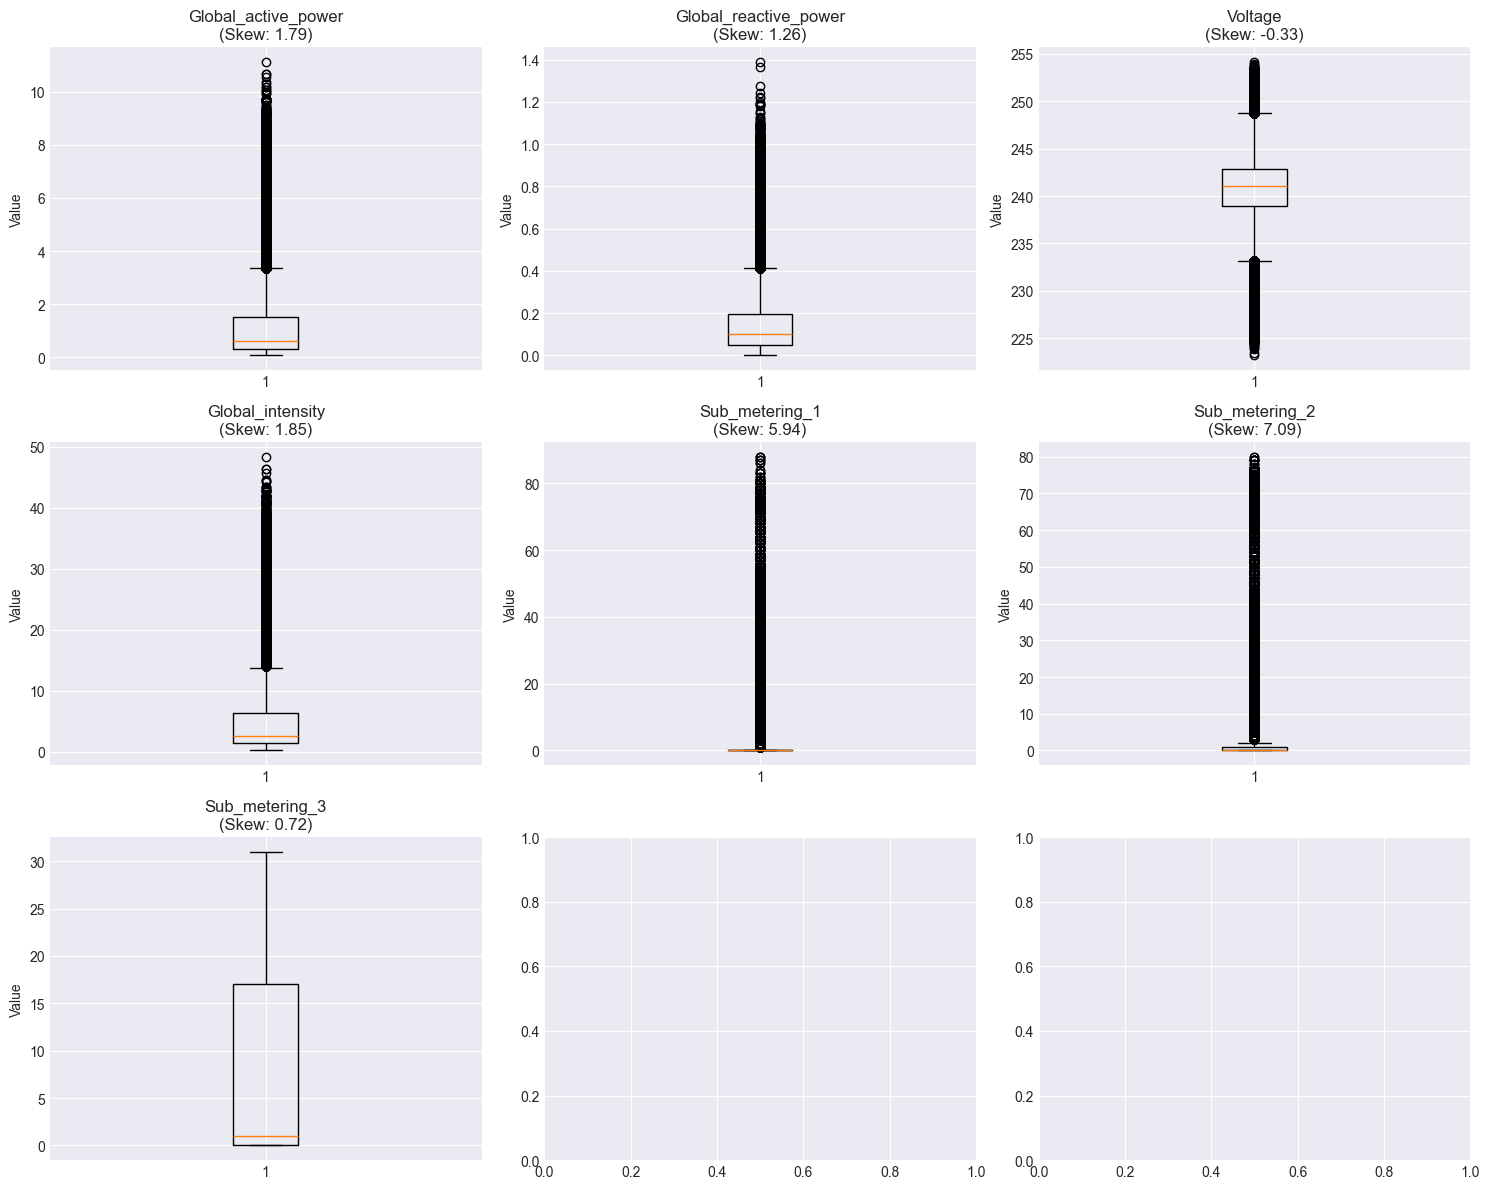

Boxplot saved to: outputs/figures/outliers_boxplot.png
Note: Log scale applied to highly skewed columns: Sub_metering_1, Sub_metering_2
Outlier Treatment: Winsorization at 99th percentile
Global_active_power: Capping 39389 values (1.92%)
Global_reactive_power: Capping 20277 values (0.99%)
Voltage: Capping 40898 values (2.00%)
Global_intensity: Capping 40494 values (1.98%)
Sub_metering_1: Capping 10724 values (0.52%)
Sub_metering_2: Capping 19799 values (0.97%)
Sub_metering_3: Capping 20293 values (0.99%)

Outlier treatment complete.
Creating time-based features...
Time-based features created:
  - year
  - month
  - day
  - hour
  - minute
  - day_of_week
  - day_of_year
  - week_of_year
  - quarter
  - is_weekend
  - time_of_day
  - season
Final Data Quality Report:

Shape: 2,049,280 rows × 20 columns
Missing values: 0
Duplicate rows: 0
Memory usage: 444.29 MB

Data types:
datetime                 datetime64[us]
Global_active_power             float64
Global_reactive_power           fl

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,day,hour,minute,day_of_week,day_of_year,week_of_year,quarter,is_weekend,time_of_day,season
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,12,16,17,24,5,350,50,4,1,Afternoon,Winter
1,2006-12-16 17:25:00,4.850,0.436,233.63,20.6,0.0,1.0,16.0,2006,12,16,17,25,5,350,50,4,1,Afternoon,Winter
2,2006-12-16 17:26:00,4.850,0.478,233.29,20.6,0.0,2.0,17.0,2006,12,16,17,26,5,350,50,4,1,Afternoon,Winter
3,2006-12-16 17:27:00,4.850,0.478,233.74,20.6,0.0,1.0,17.0,2006,12,16,17,27,5,350,50,4,1,Afternoon,Winter
4,2006-12-16 17:28:00,3.666,0.478,235.68,15.8,0.0,1.0,17.0,2006,12,16,17,28,5,350,50,4,1,Afternoon,Winter
5,2006-12-16 17:29:00,3.520,0.478,235.02,15.0,0.0,2.0,17.0,2006,12,16,17,29,5,350,50,4,1,Afternoon,Winter
6,2006-12-16 17:30:00,3.702,0.478,235.09,15.8,0.0,1.0,17.0,2006,12,16,17,30,5,350,50,4,1,Afternoon,Winter
7,2006-12-16 17:31:00,3.700,0.478,235.22,15.8,0.0,1.0,17.0,2006,12,16,17,31,5,350,50,4,1,Afternoon,Winter
8,2006-12-16 17:32:00,3.668,0.478,233.99,15.8,0.0,1.0,17.0,2006,12,16,17,32,5,350,50,4,1,Afternoon,Winter
9,2006-12-16 17:33:00,3.662,0.478,233.86,15.8,0.0,2.0,16.0,2006,12,16,17,33,5,350,50,4,1,Afternoon,Winter


Saving cleaned data...
Saved: data/processed/df_cleaned.pkl
Saved: data/processed/df_cleaned.csv

DATA CLEANING COMPLETE

SUCCESS: 02_data_cleaning.ipynb completed successfully!
Duration: 14.15 seconds

EXECUTING: 03_exploratory_analysis.ipynb
Libraries imported successfully!
Data loaded: 2,049,280 rows × 20 columns
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Statistical Summary:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.083105e+00,1.227744e-01,2.408445e+02,4.593066e+00,1.096591e+00,1.215729e+00,6.382375e+00
std,1.018938e+00,1.088884e-01,3.164123e+00,4.272706e+00,5.956240e+00,5.080553e+00,8.275064e+00
min,1.100000e-01,0.000000e+00,2.321400e+02,6.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,4.850000e+00,4.780000e-01,2.482700e+02,2.060000e+01,3.800000e+01,3.600000e+01,2.000000e+01


Skewness and Kurtosis Analysis:


,Column,Skewness,Kurtosis
0,Global_active_power,1.496415,2.108814
1,Global_reactive_power,0.960177,0.624312
2,Voltage,-0.275299,0.175423
3,Global_intensity,1.542325,2.300790
4,Sub_metering_1,5.731769,31.398504
5,Sub_metering_2,5.979129,35.505058
6,Sub_metering_3,0.665802,-1.507504


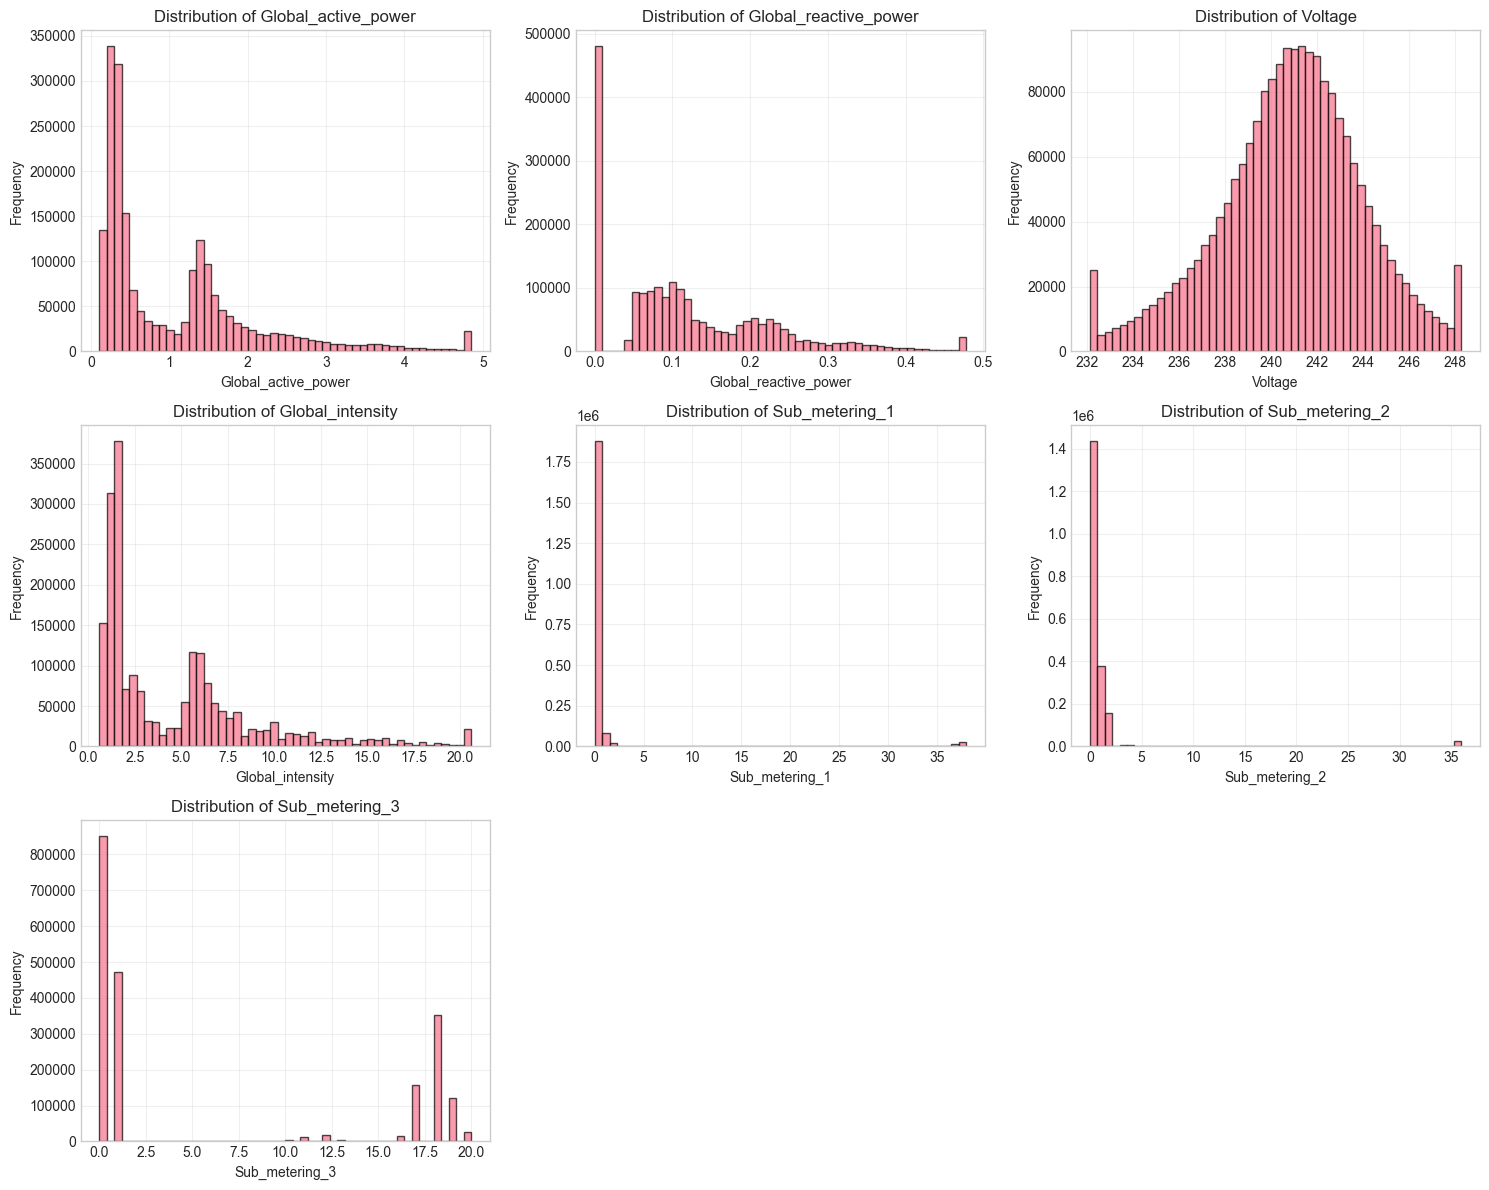

Saved: outputs/figures/distributions.png


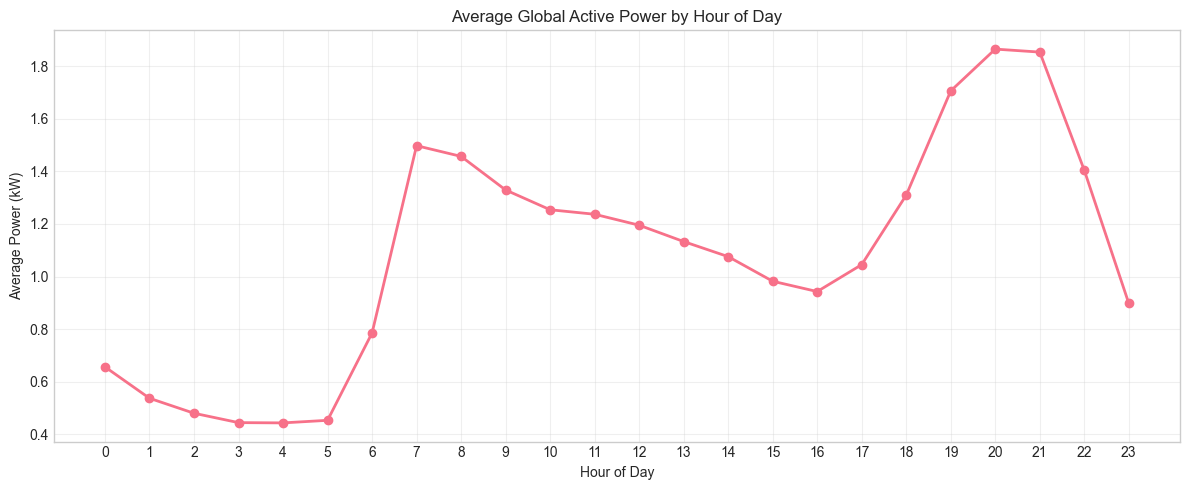

Saved: outputs/figures/hourly_pattern.png


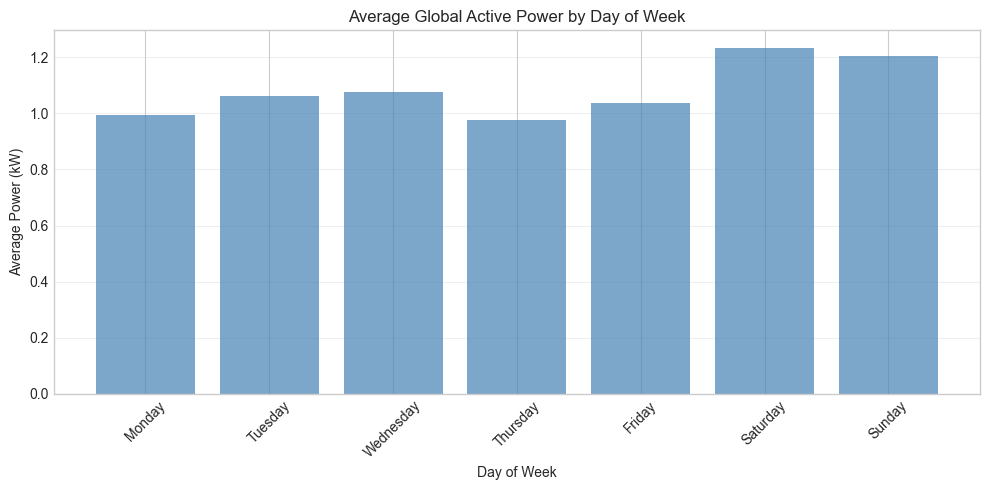

Saved: outputs/figures/daily_pattern.png


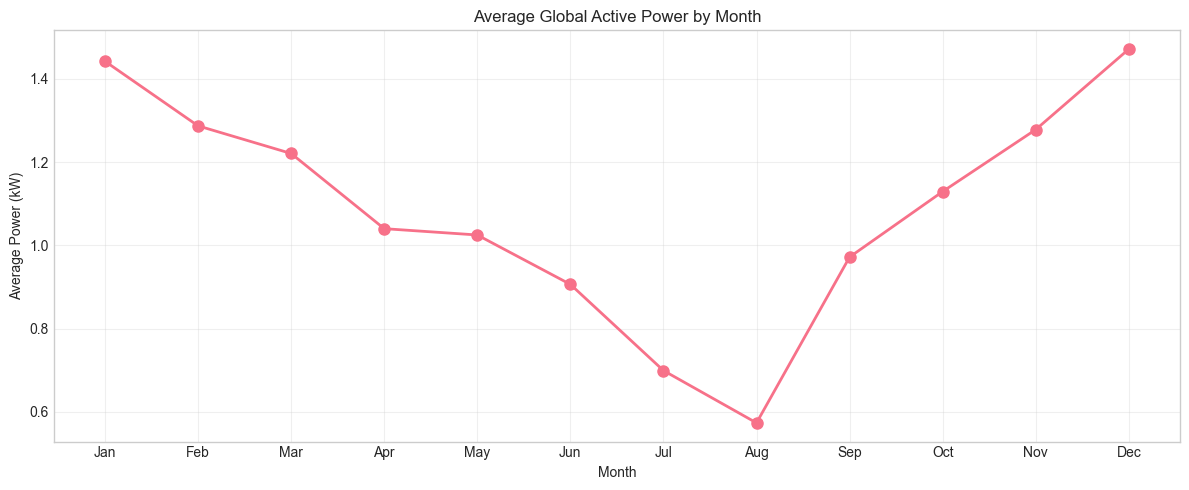

Saved: outputs/figures/monthly_pattern.png


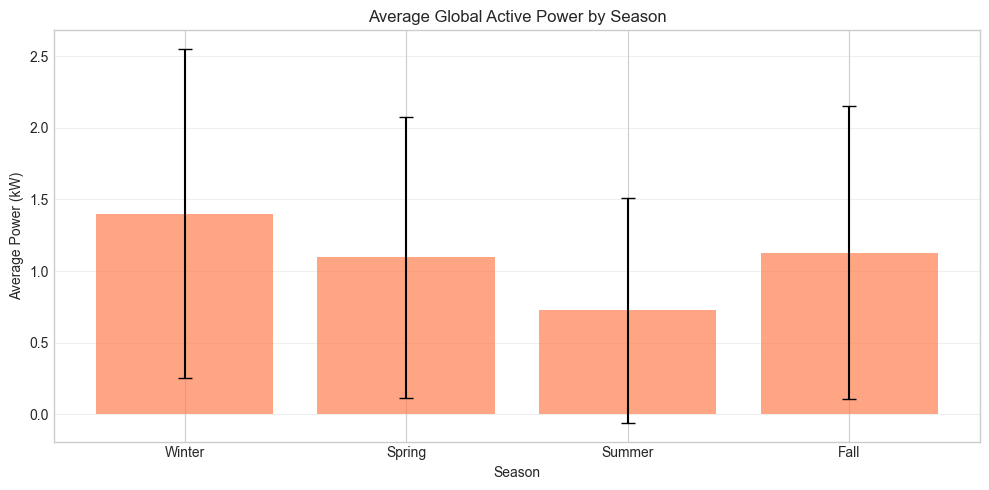

Saved: outputs/figures/seasonal_pattern.png


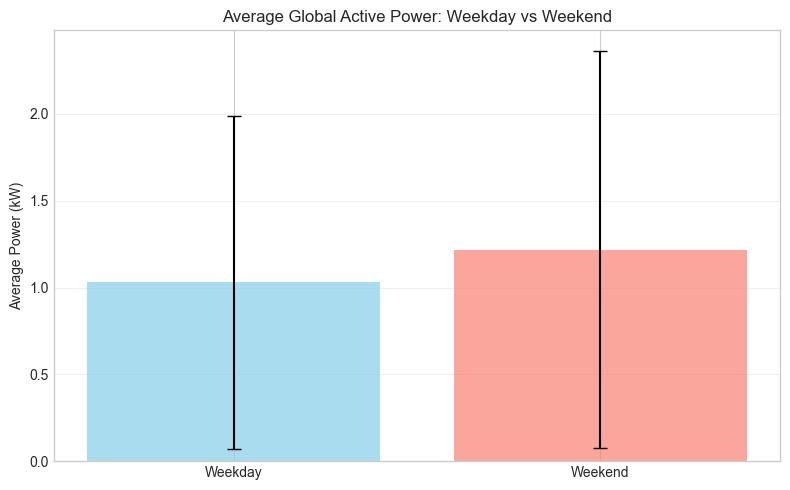

Saved: outputs/figures/weekend_comparison.png


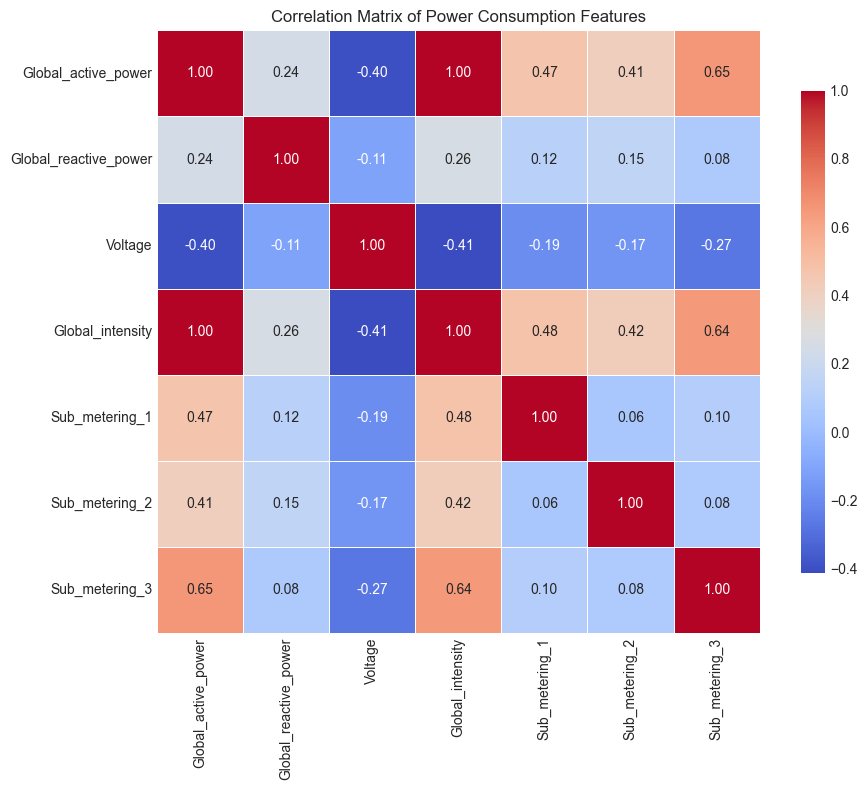

Saved: outputs/figures/correlation_matrix.png
Creating pairplot (this may take a moment)...


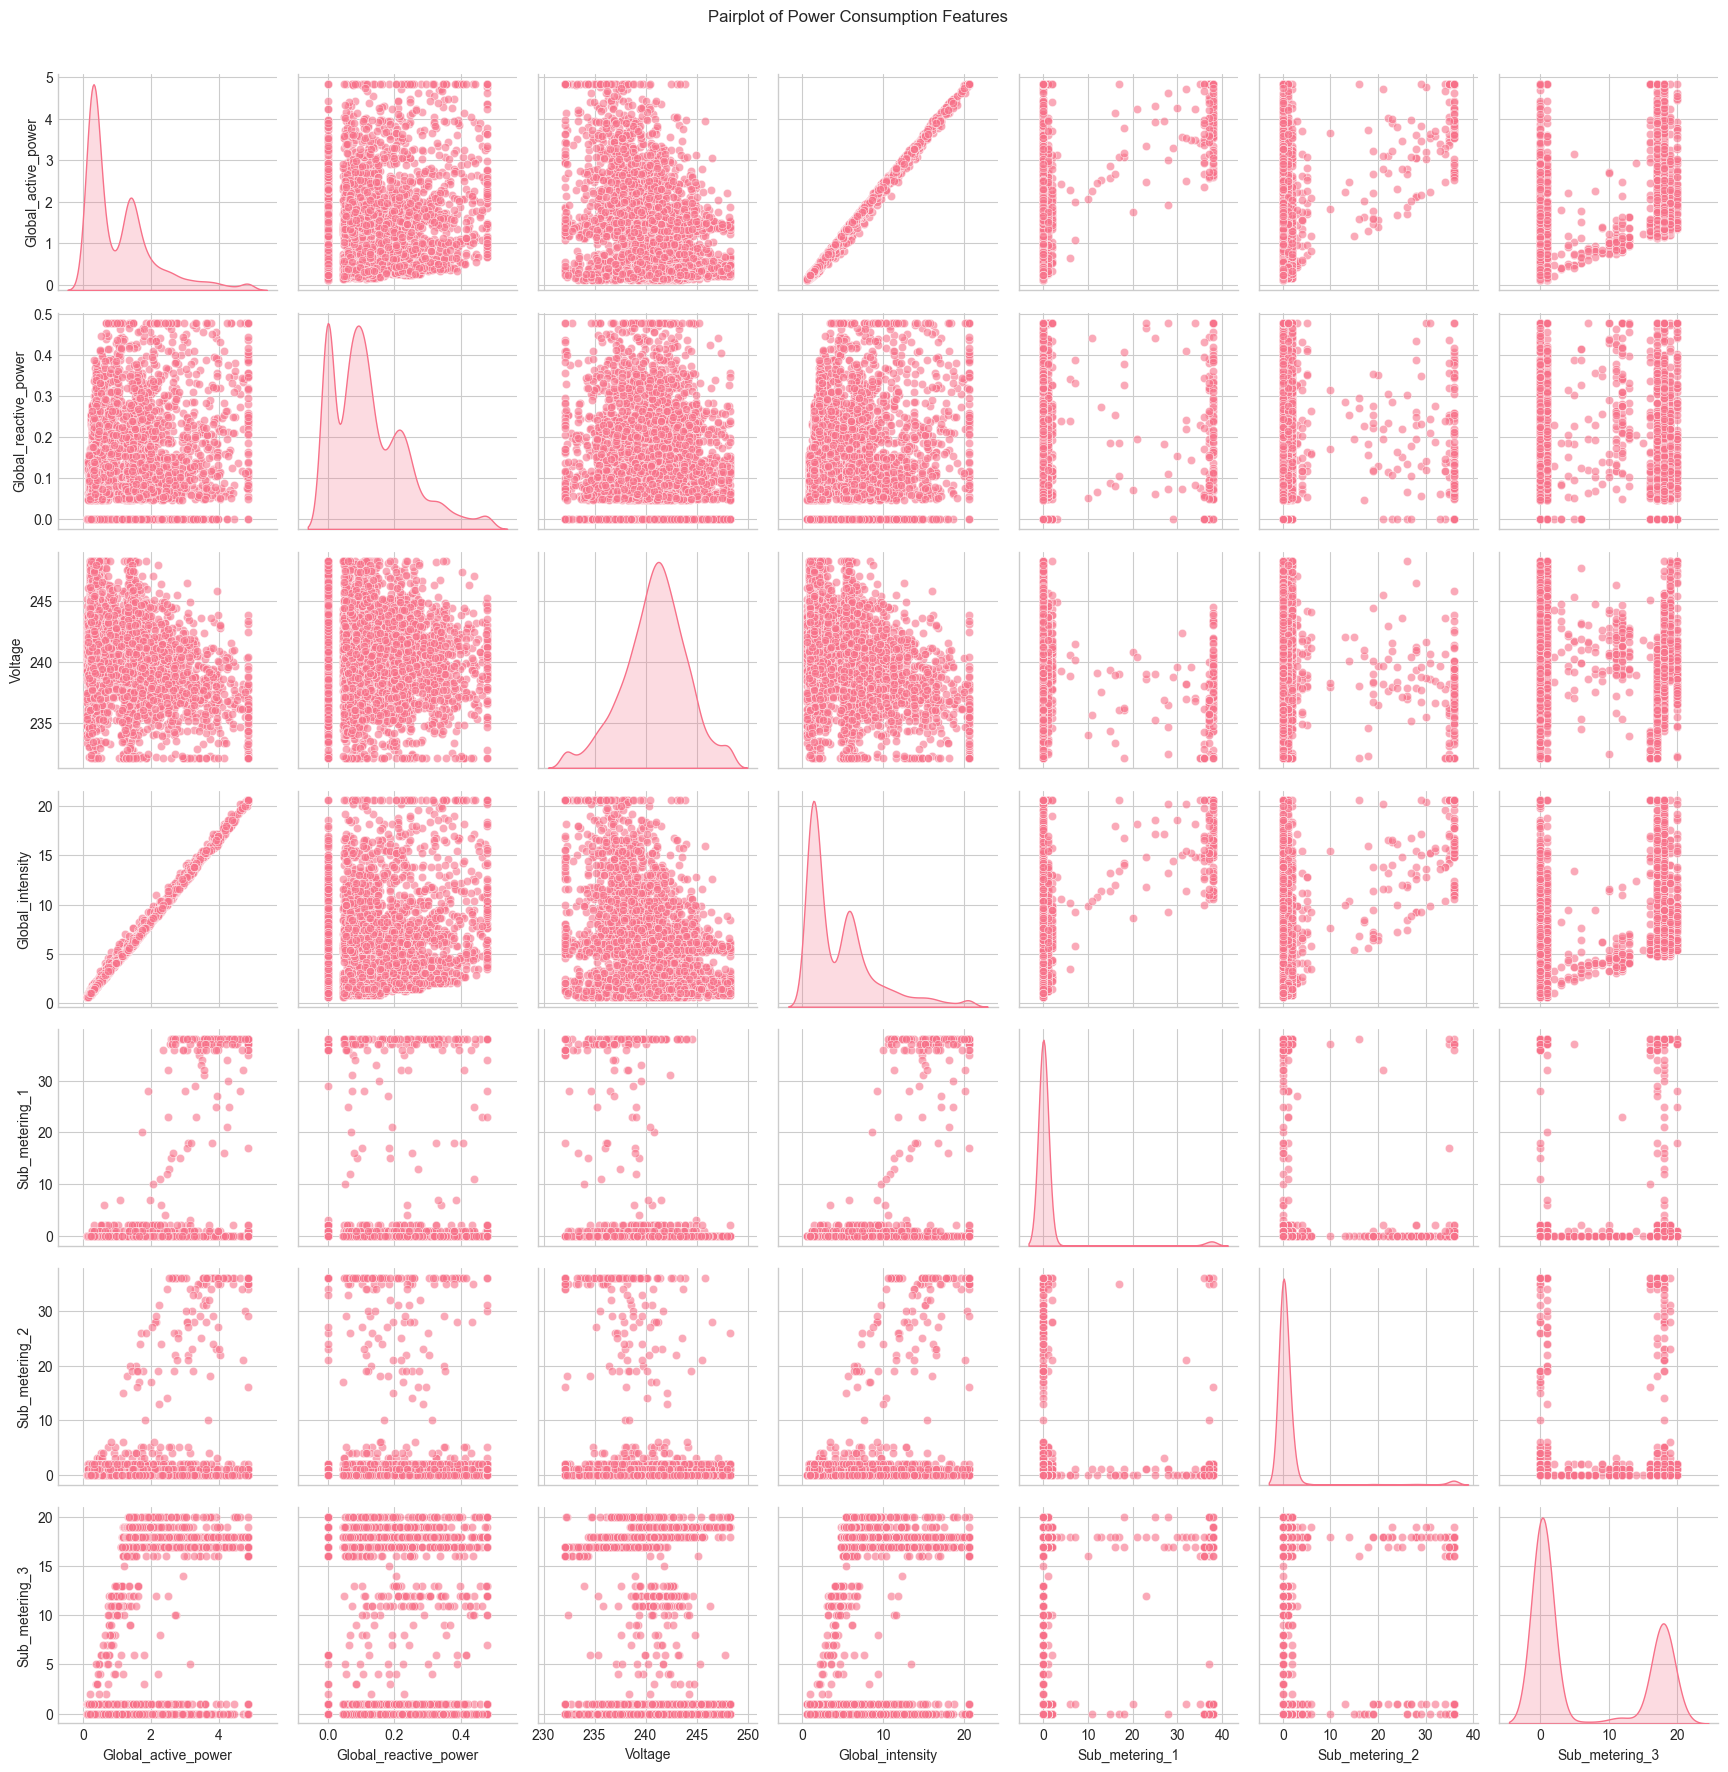

Saved: outputs/figures/pairplot.png


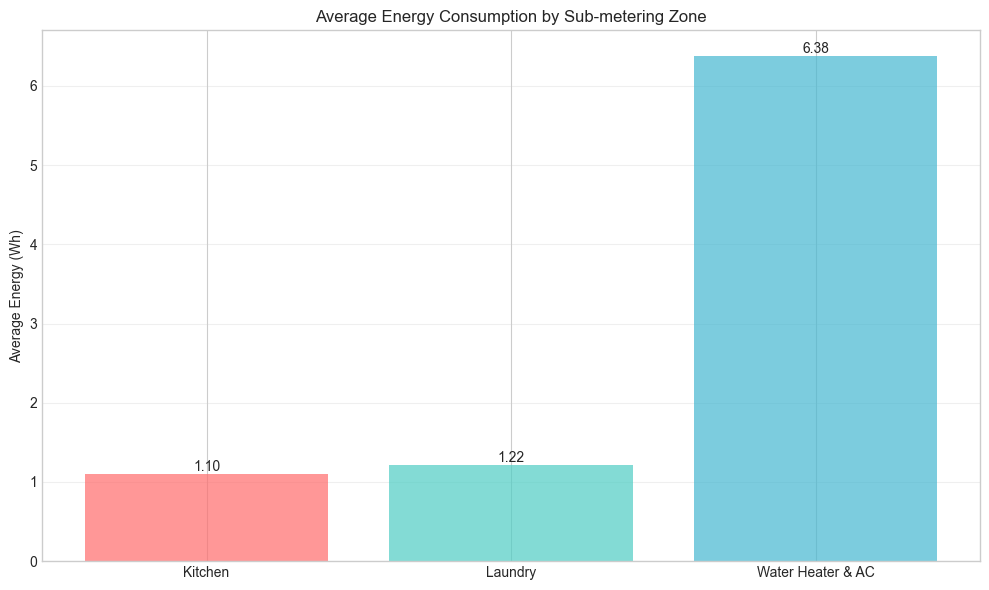

Saved: outputs/figures/submetering_comparison.png


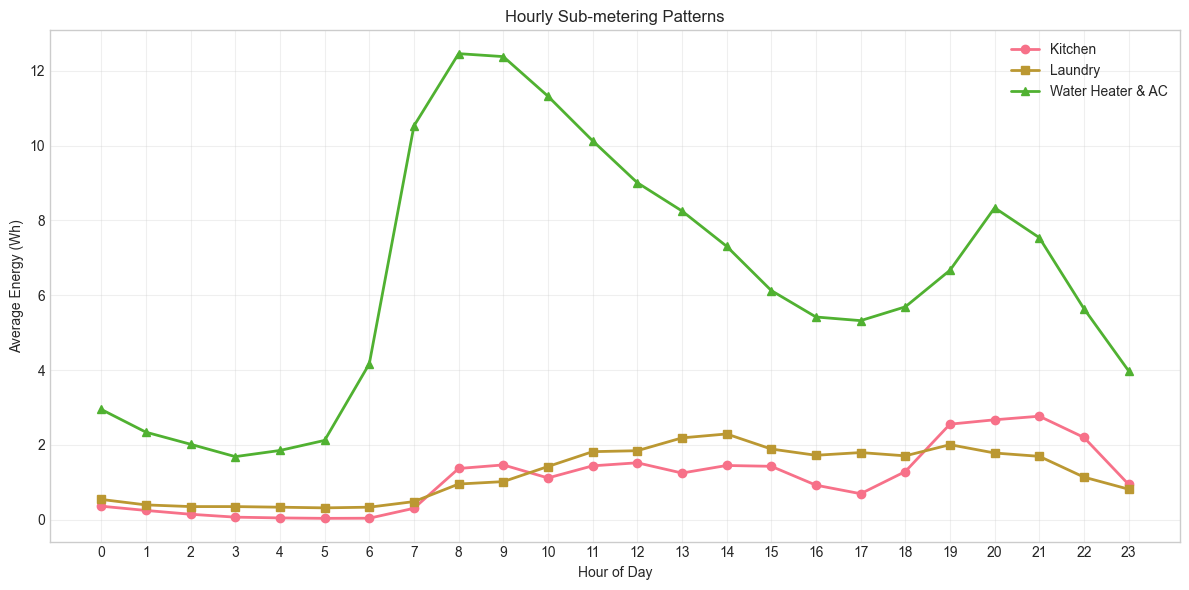

Saved: outputs/figures/hourly_submetering.png


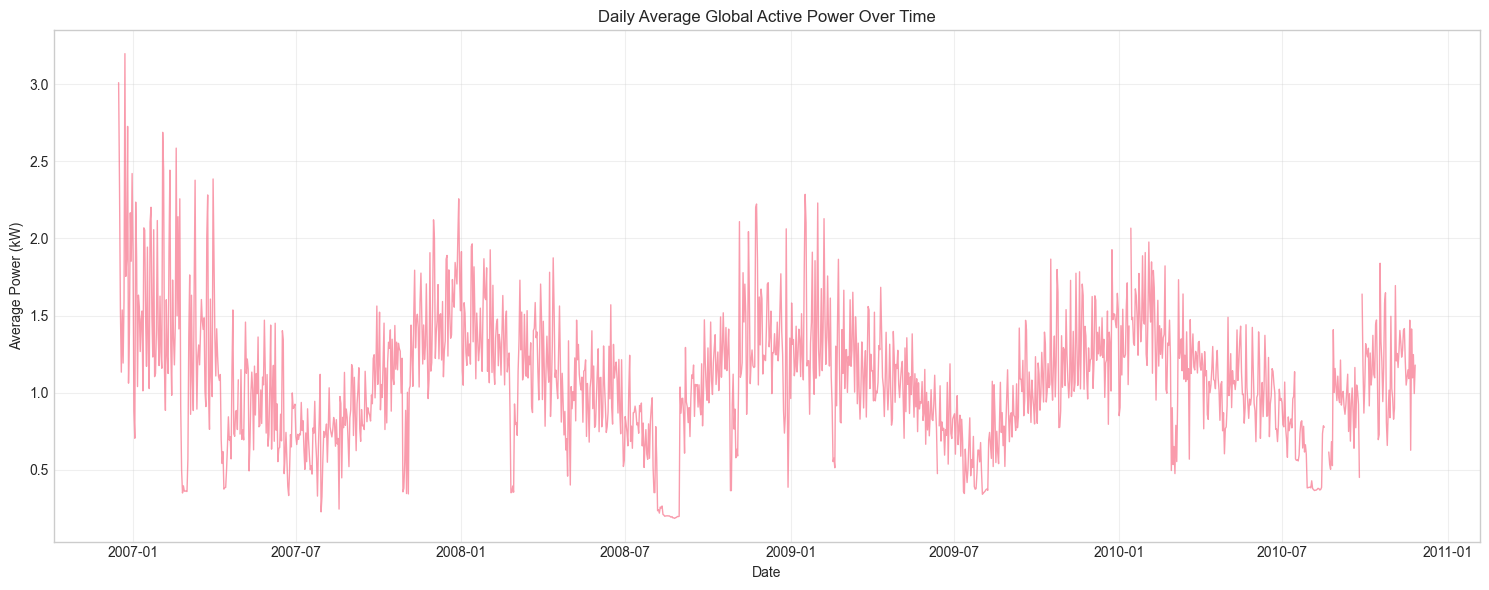

Saved: outputs/figures/timeseries_daily.png


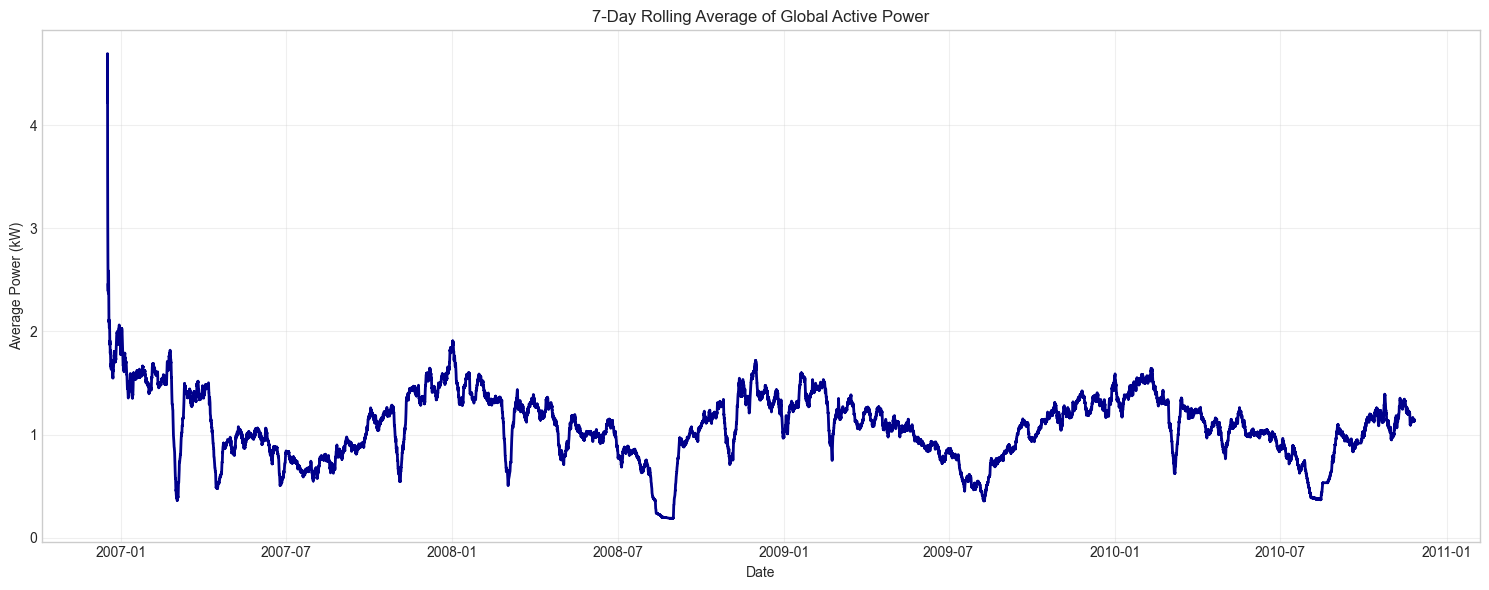

Saved: outputs/figures/timeseries_rolling.png
Number of anomalies detected: 40,820
Percentage of anomalies: 1.99%

Sample anomalies:


,datetime,Global_active_power,z_score
0,2006-12-16 17:24:00,4.216,3.074666
1,2006-12-16 17:25:00,4.850,3.696883
2,2006-12-16 17:26:00,4.850,3.696883
3,2006-12-16 17:27:00,4.850,3.696883
10,2006-12-16 17:34:00,4.448,3.302354
11,2006-12-16 17:35:00,4.850,3.696883
12,2006-12-16 17:36:00,4.850,3.696883
13,2006-12-16 17:37:00,4.850,3.696883
20,2006-12-16 17:44:00,4.850,3.696883
21,2006-12-16 17:45:00,4.850,3.696883


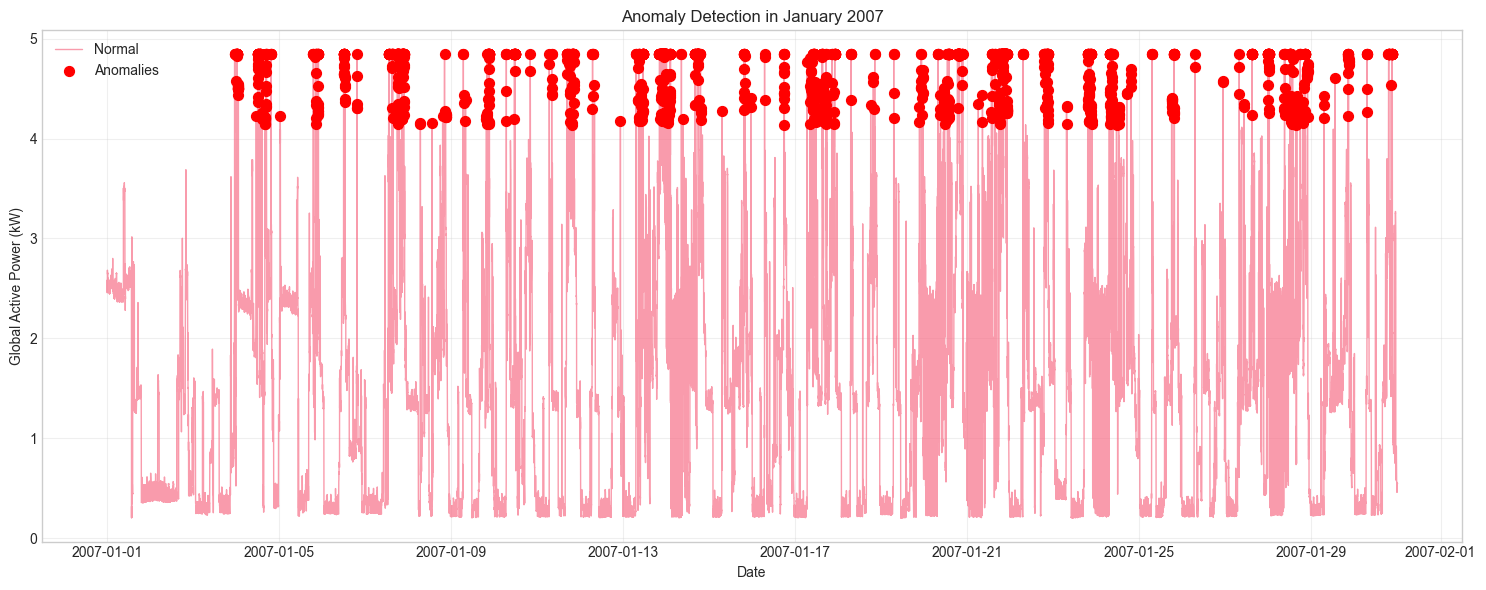

Saved: outputs/figures/anomalies.png
KEY INSIGHTS:
1. Peak consumption hour: 20:00
2. Lowest consumption hour: 4:00
3. Peak consumption season: Winter
4. Weekend consumption is higher than weekday
5. Highest consuming zone: Water Heater & AC

SUCCESS: 03_exploratory_analysis.ipynb completed successfully!
Duration: 12.07 seconds

EXECUTING: 04_feature_engineering.ipynb
Libraries imported successfully!
Data loaded: 2,049,280 rows × 20 columns
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data sorted by datetime
Creating lag features for Global_active_power...
  - Lag 1 created
  - Lag 60 created
  - Lag 1440 created
  - Lag 10080 created

Total features after lag creation: 24


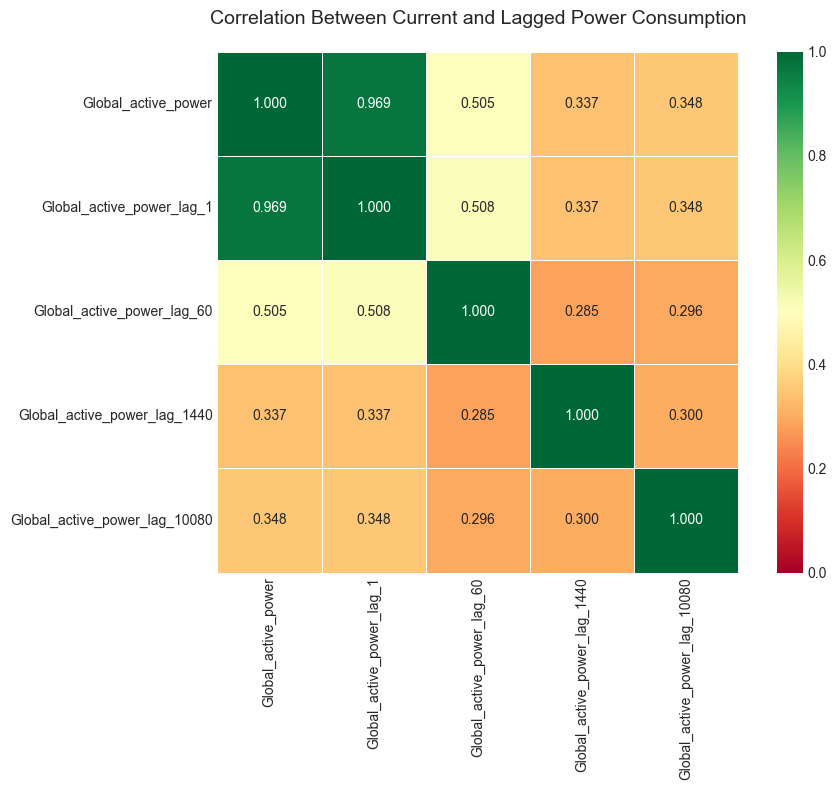

Saved: outputs/figures/lag_correlations.png

Lag Feature Correlations with Current Value:
  Global_active_power_lag_1: 0.9691
  Global_active_power_lag_60: 0.5050
  Global_active_power_lag_1440: 0.3374
  Global_active_power_lag_10080: 0.3481
Creating rolling window features...
  - Window 60 features created
  - Window 360 features created
  - Window 1440 features created

Total features: 36


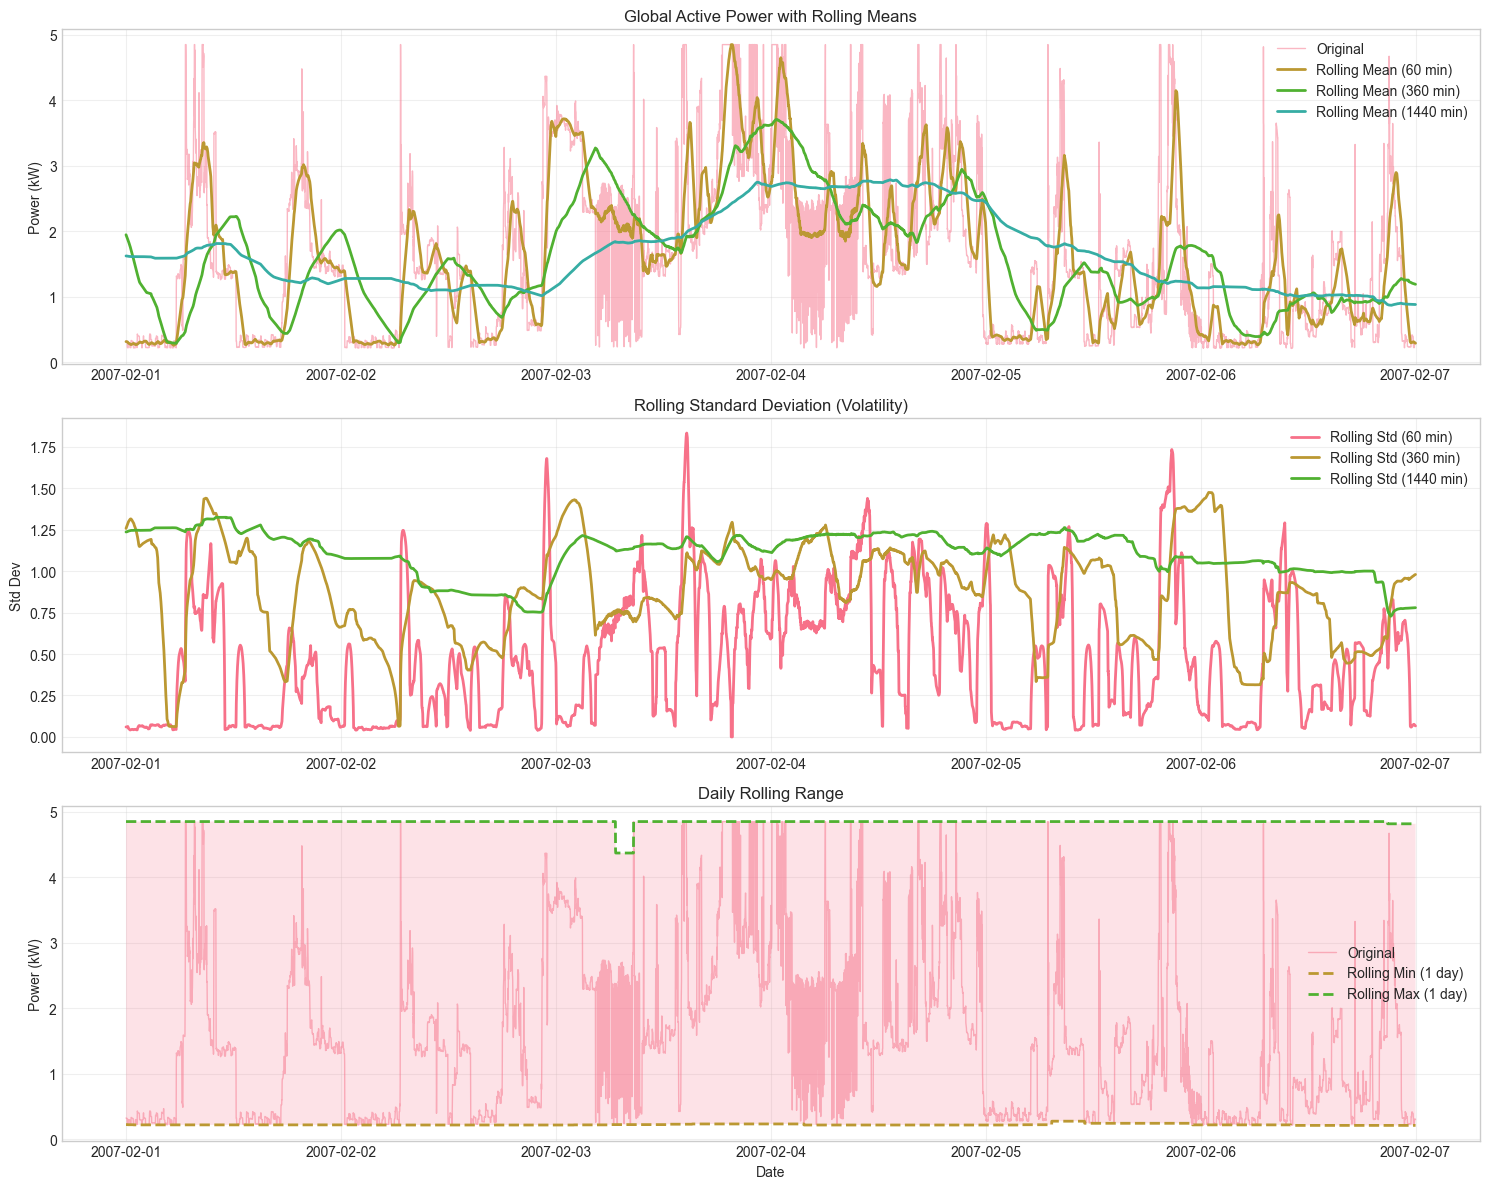

Saved: outputs/figures/rolling_features.png
Creating rate of change features...
Rate of change features created
Total features: 41


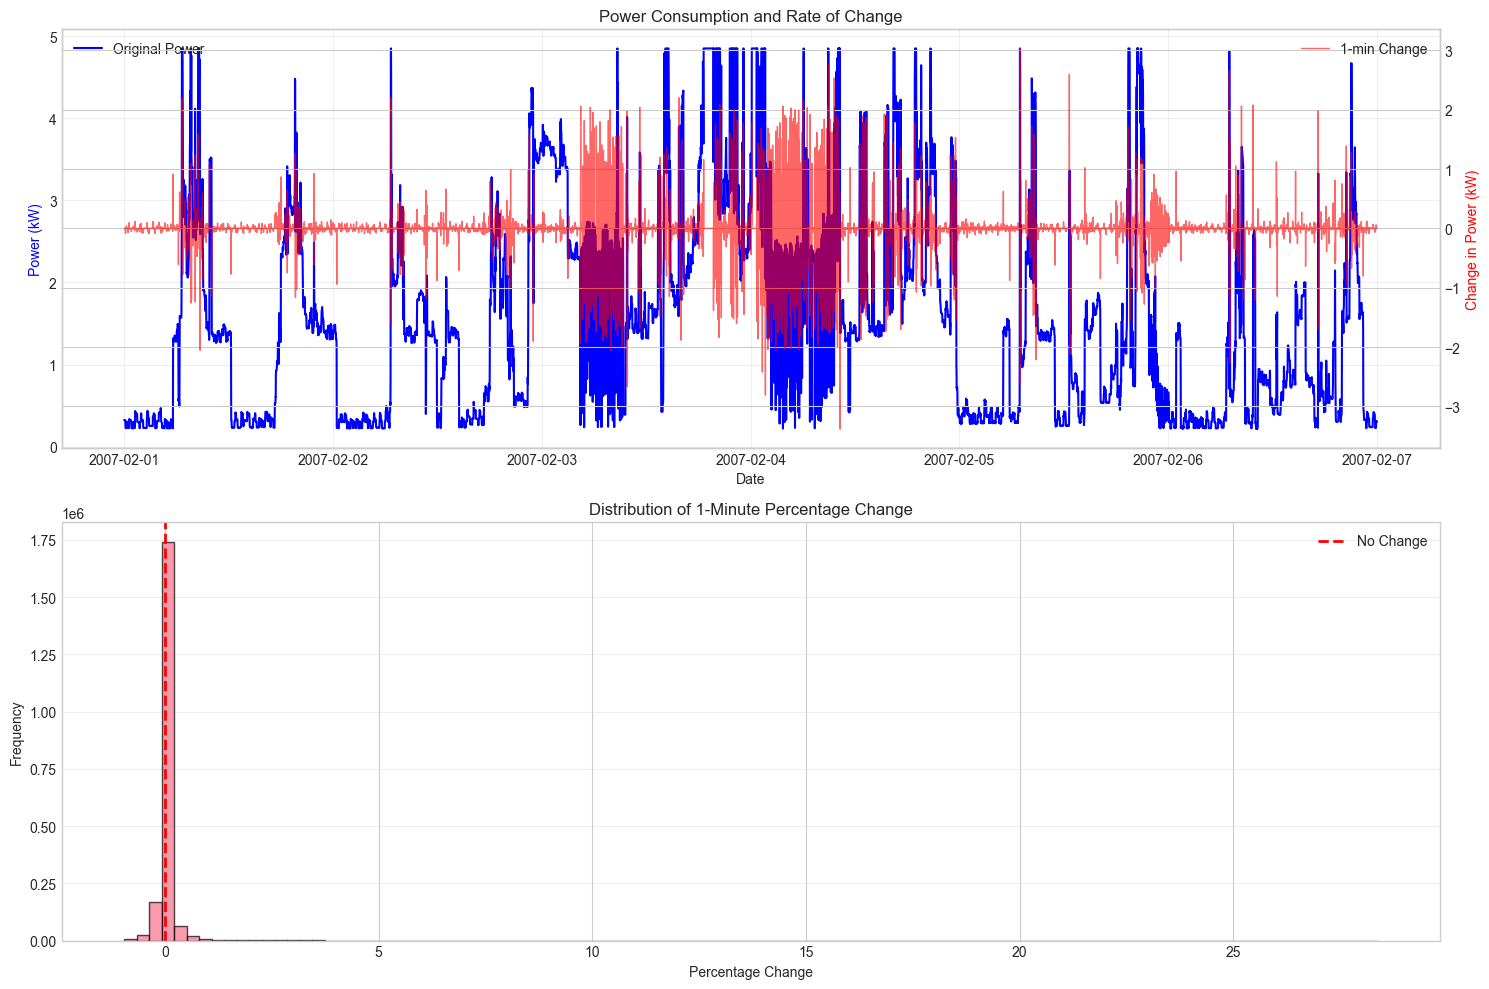

Saved: outputs/figures/rate_of_change.png
Creating cyclical time features...
Cyclical features created
Total features: 49


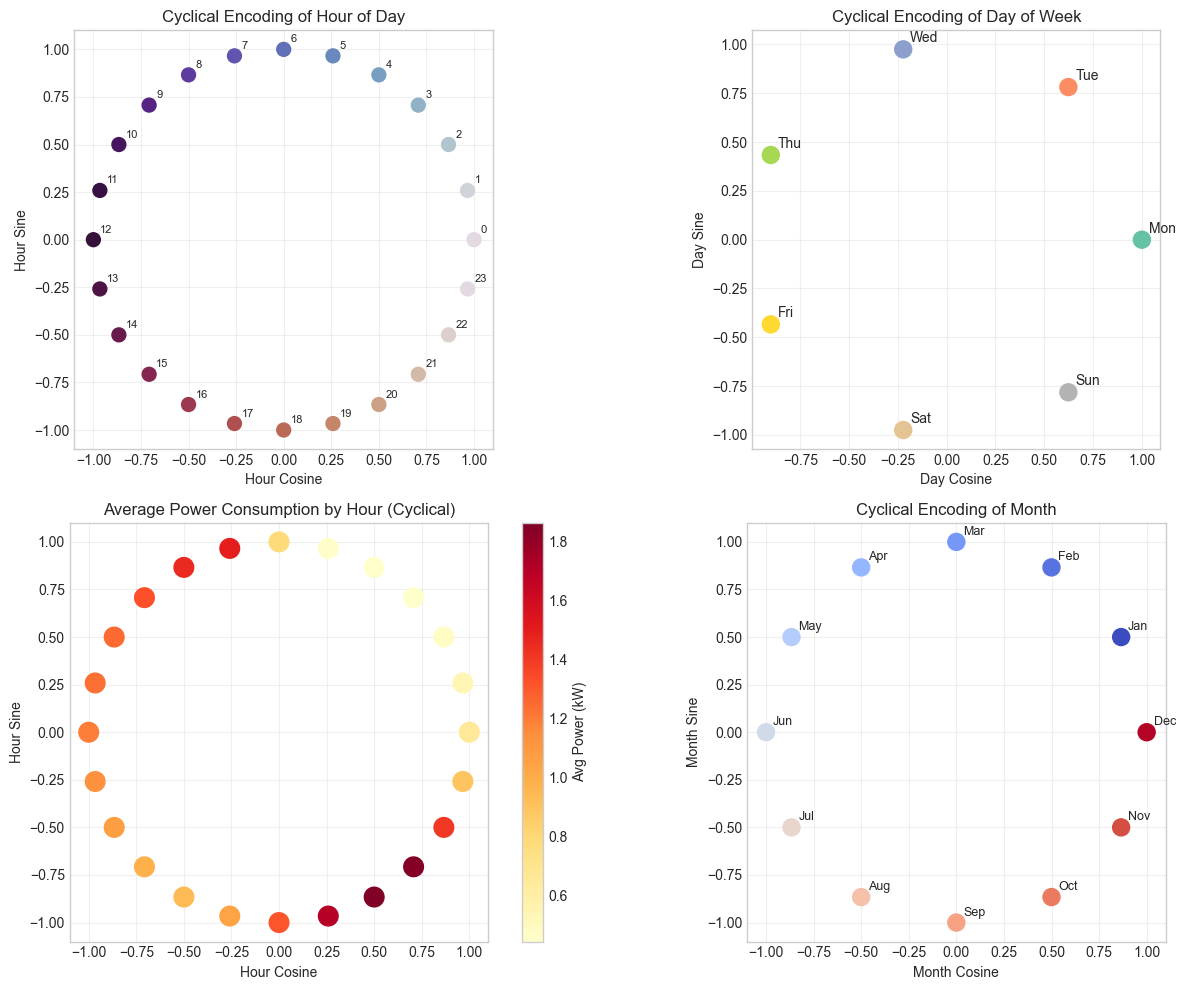

Saved: outputs/figures/cyclical_features.png
Creating interaction features...
Interaction features created
Total features: 53


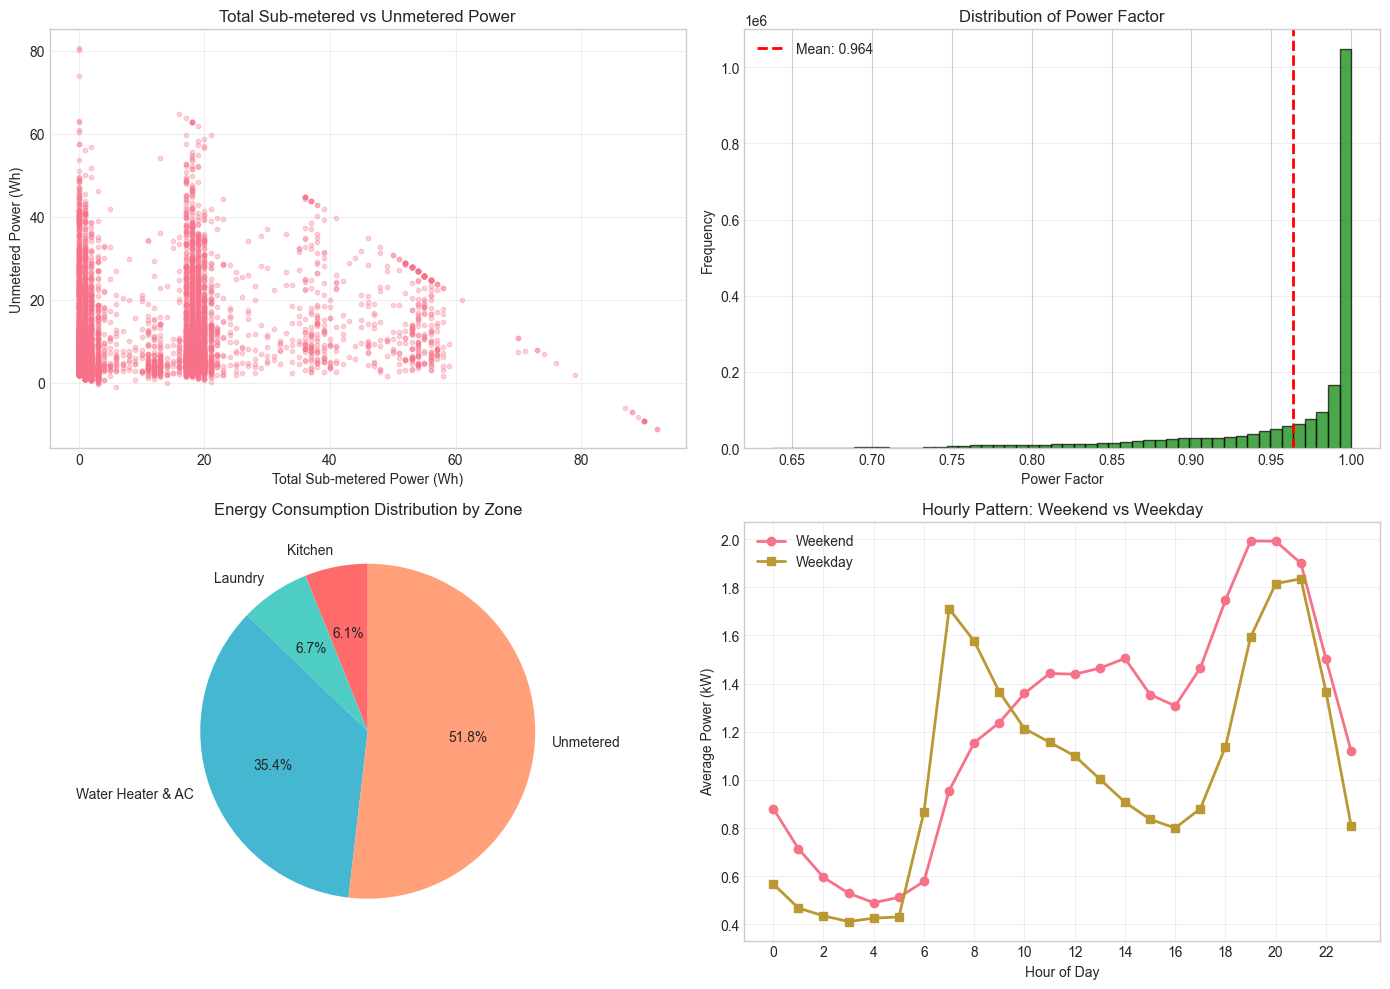

Saved: outputs/figures/interaction_features.png
Feature Engineering Summary

Total features created: 53
Total records: 2,049,280

Original features: 8
Time-based features: 21
Lag features: 4
Rolling window features: 12
Rate of change features: 5
Cyclical features: 8
Interaction features: 4

Missing values after feature engineering:

Columns with missing values:


Global_active_power_lag_10080           10080
Global_active_power_lag_1440             1440
Global_active_power_diff_1440            1440
Global_active_power_lag_60                 60
Global_active_power_pct_change_60          60
Global_active_power_diff_60                60
Global_active_power_lag_1                   1
Global_active_power_rolling_std_60          1
Global_active_power_diff_1                  1
Global_active_power_rolling_std_1440        1
Global_active_power_rolling_std_360         1
Global_active_power_pct_change_1            1
dtype: int64


Note: Missing values in lag and rolling features are expected at the start of the series.
Saving dataset with engineered features...
Rows after removing NaN: 2,039,200
Rows removed: 10,080
Saved: data/processed/df_features.pkl
Saved: data/processed/feature_list.csv

FEATURE ENGINEERING COMPLETE

SUCCESS: 04_feature_engineering.ipynb completed successfully!
Duration: 7.05 seconds

EXECUTING: 05_modeling_preparation.ipynb
Libraries imported successfully!
Data loaded: 2,039,200 rows × 53 columns
Date range: 2006-12-23 17:26:00 to 2010-11-26 21:02:00
Memory usage: 939.95 MB
Target variable: Global_active_power
Number of features: 46

Feature categories:
  - Original measurements: Sub_metering_1/2/3, Voltage
  - Time features: hour, day, month, etc.
  - Lag features: 4
  - Rolling features: 12
  - Rate of change: 5
  - Cyclical features: 8
Data Split Summary:

Training set:
  - Size: 1,427,440 samples (70.0%)
  - Date range: 2006-12-23 17:26:00 to 2009-09-15 19:07:00

Validation set:
  - S

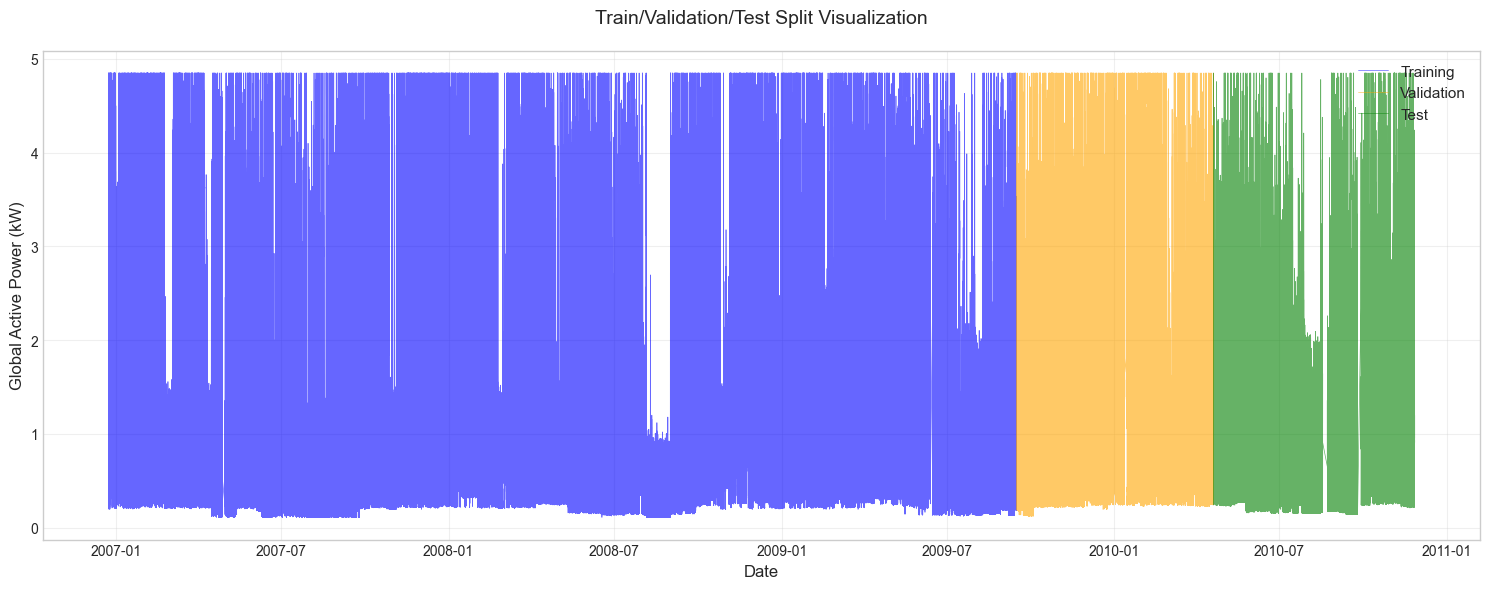

Saved: outputs/figures/train_val_test_split.png
Feature matrices prepared:
X_train shape: (1427440, 46)
X_val shape: (305880, 46)
X_test shape: (305880, 46)
Features scaled using StandardScaler

Scaled training set statistics:
Mean: 0.000000
Std: 1.000000


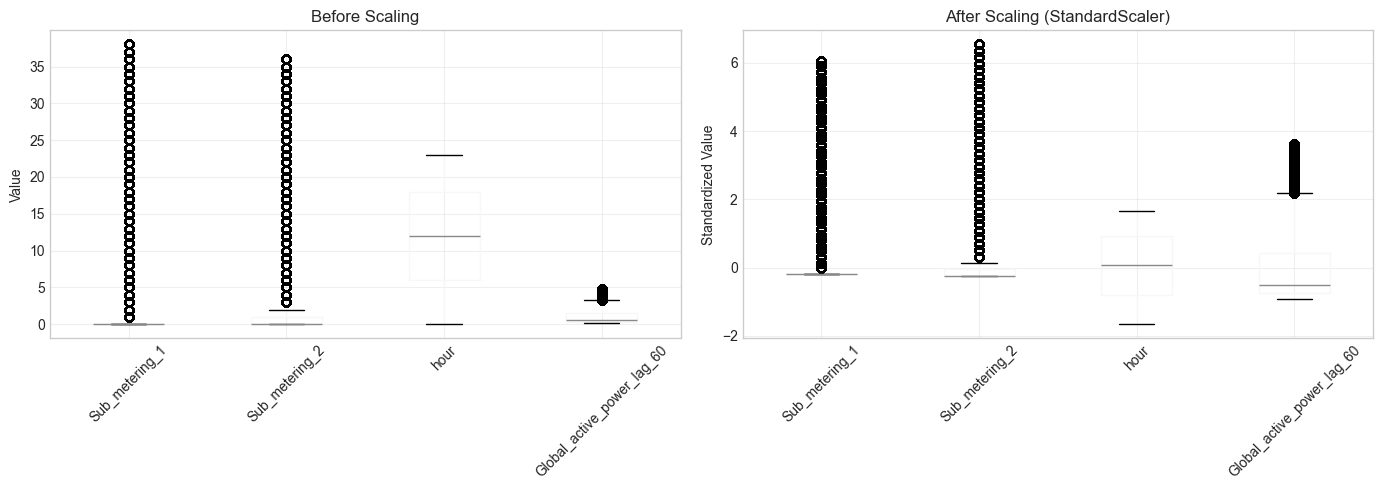

Saved: outputs/figures/feature_scaling.png
Evaluation function defined
Baseline 1: Naive Forecast (Previous Value)

Naive Baseline (Validation) Performance Metrics:
  MAE:  0.0795 kW
  RMSE: 0.2401 kW
  R²:   0.9445
  MAPE: 6.29%

Naive Baseline (Test) Performance Metrics:
  MAE:  0.0707 kW
  RMSE: 0.2159 kW
  R²:   0.9353
  MAPE: 7.79%

Baseline 2: Mean Forecast
Training mean: 1.0716 kW

Mean Baseline (Validation) Performance Metrics:
  MAE:  0.8085 kW
  RMSE: 1.0335 kW
  R²:   -0.0283
  MAPE: 119.54%

Mean Baseline (Test) Performance Metrics:
  MAE:  0.7032 kW
  RMSE: 0.8565 kW
  R²:   -0.0189
  MAPE: 153.65%

Baseline 3: Linear Regression

Linear Regression (Validation) Performance Metrics:
  MAE:  0.0000 kW
  RMSE: 0.0000 kW
  R²:   1.0000
  MAPE: 0.00%

Linear Regression (Test) Performance Metrics:
  MAE:  0.0000 kW
  RMSE: 0.0000 kW
  R²:   1.0000
  MAPE: 0.00%
Training Random Forest baseline...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    2.3s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


Random Forest trained

Random Forest (Validation) Performance Metrics:
  MAE:  0.0085 kW
  RMSE: 0.0292 kW
  R²:   0.9992
  MAPE: 0.61%

Random Forest (Test) Performance Metrics:
  MAE:  0.0071 kW
  RMSE: 0.0263 kW
  R²:   0.9990
  MAPE: 0.71%

Model Comparison Summary:


[Parallel(n_jobs=24)]: Done  50 out of  50 | elapsed:    0.0s finished


,Model,MAE,RMSE,R2,MAPE
0,Naive Baseline (Validation),7.948910e-02,2.400883e-01,0.944503,6.291573e+00
1,Naive Baseline (Test),7.071539e-02,2.158509e-01,0.935288,7.791909e+00
2,Mean Baseline (Validation),8.084968e-01,1.033490e+00,-0.028346,1.195389e+02
3,Mean Baseline (Test),7.031706e-01,8.565093e-01,-0.018925,1.536465e+02
4,Linear Regression (Validation),1.762330e-13,4.064882e-13,1.000000,1.186660e-11
5,Linear Regression (Test),1.397963e-13,3.521041e-13,1.000000,1.246329e-11
6,Random Forest (Validation),8.459016e-03,2.920260e-02,0.999179,6.077594e-01
7,Random Forest (Test),7.069693e-03,2.633286e-02,0.999037,7.102992e-01


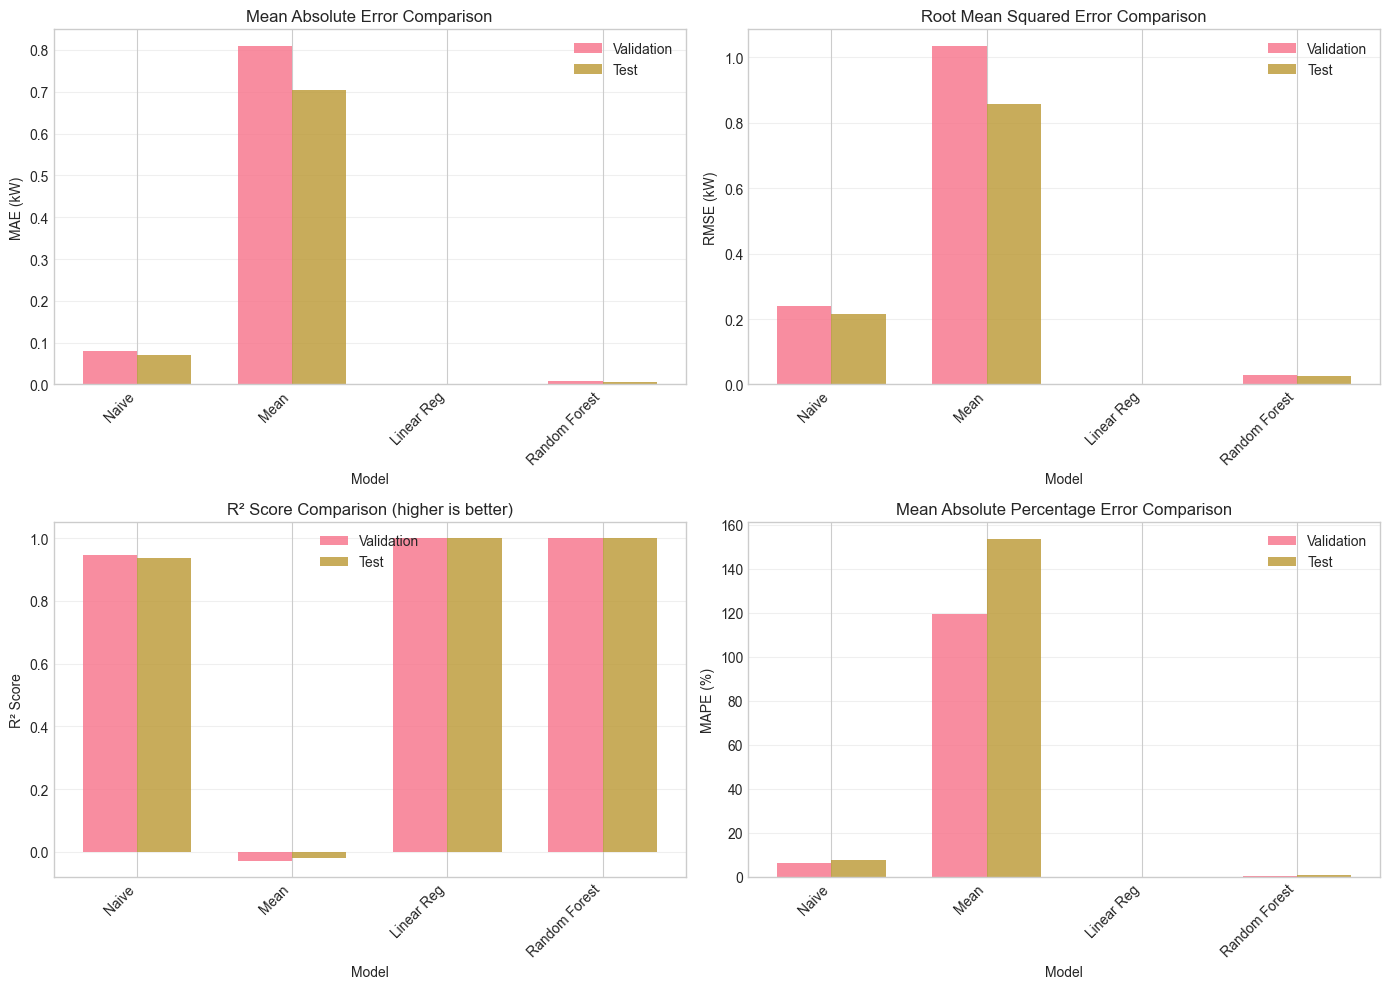

Saved: outputs/figures/baseline_comparison.png
Top 20 Most Important Features:


,Feature,Importance
13,Global_active_power_lag_1,9.407881e-01
29,Global_active_power_diff_1,2.788425e-02
32,Global_active_power_pct_change_1,2.757825e-02
43,unmetered_power,3.027253e-03
42,total_sub_metering,6.359303e-04
20,Global_active_power_rolling_max_60,5.857964e-05
2,Sub_metering_3,6.862155e-06
30,Global_active_power_diff_60,5.560726e-06
0,Sub_metering_1,5.203052e-06
19,Global_active_power_rolling_min_60,3.770415e-06


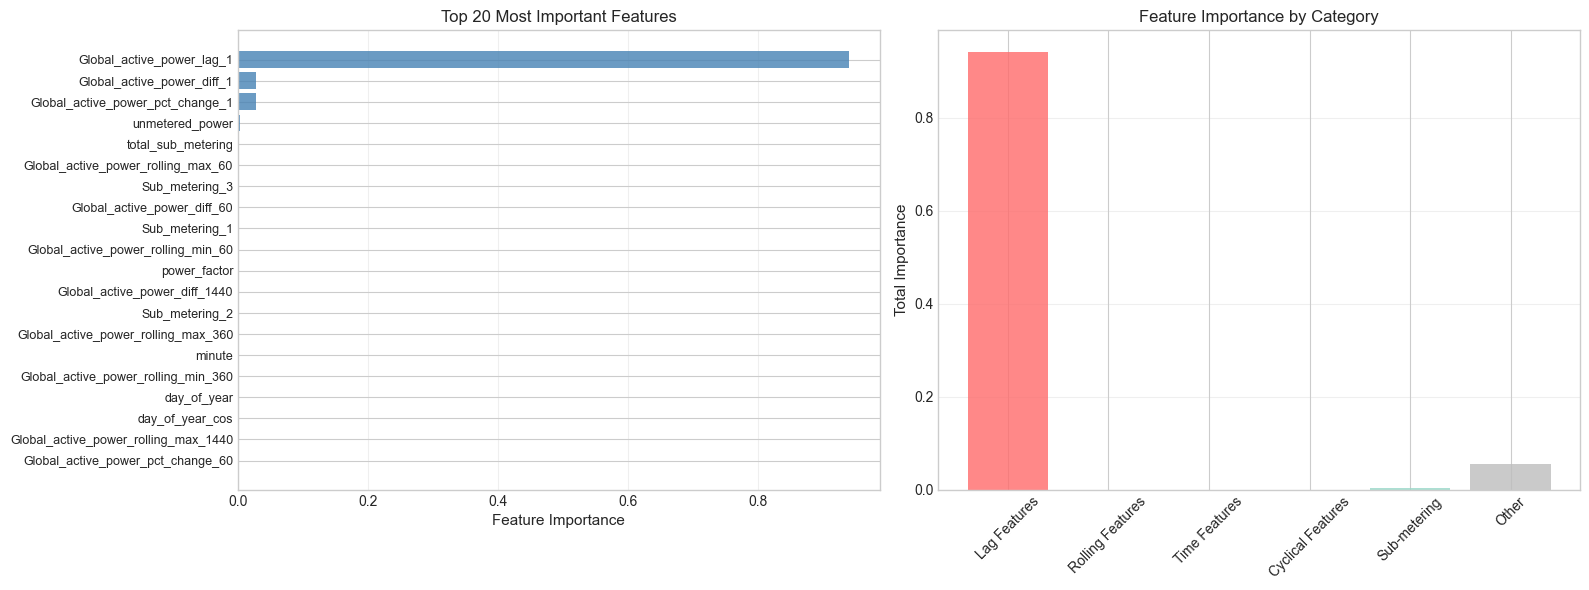

Saved: outputs/figures/feature_importance.png


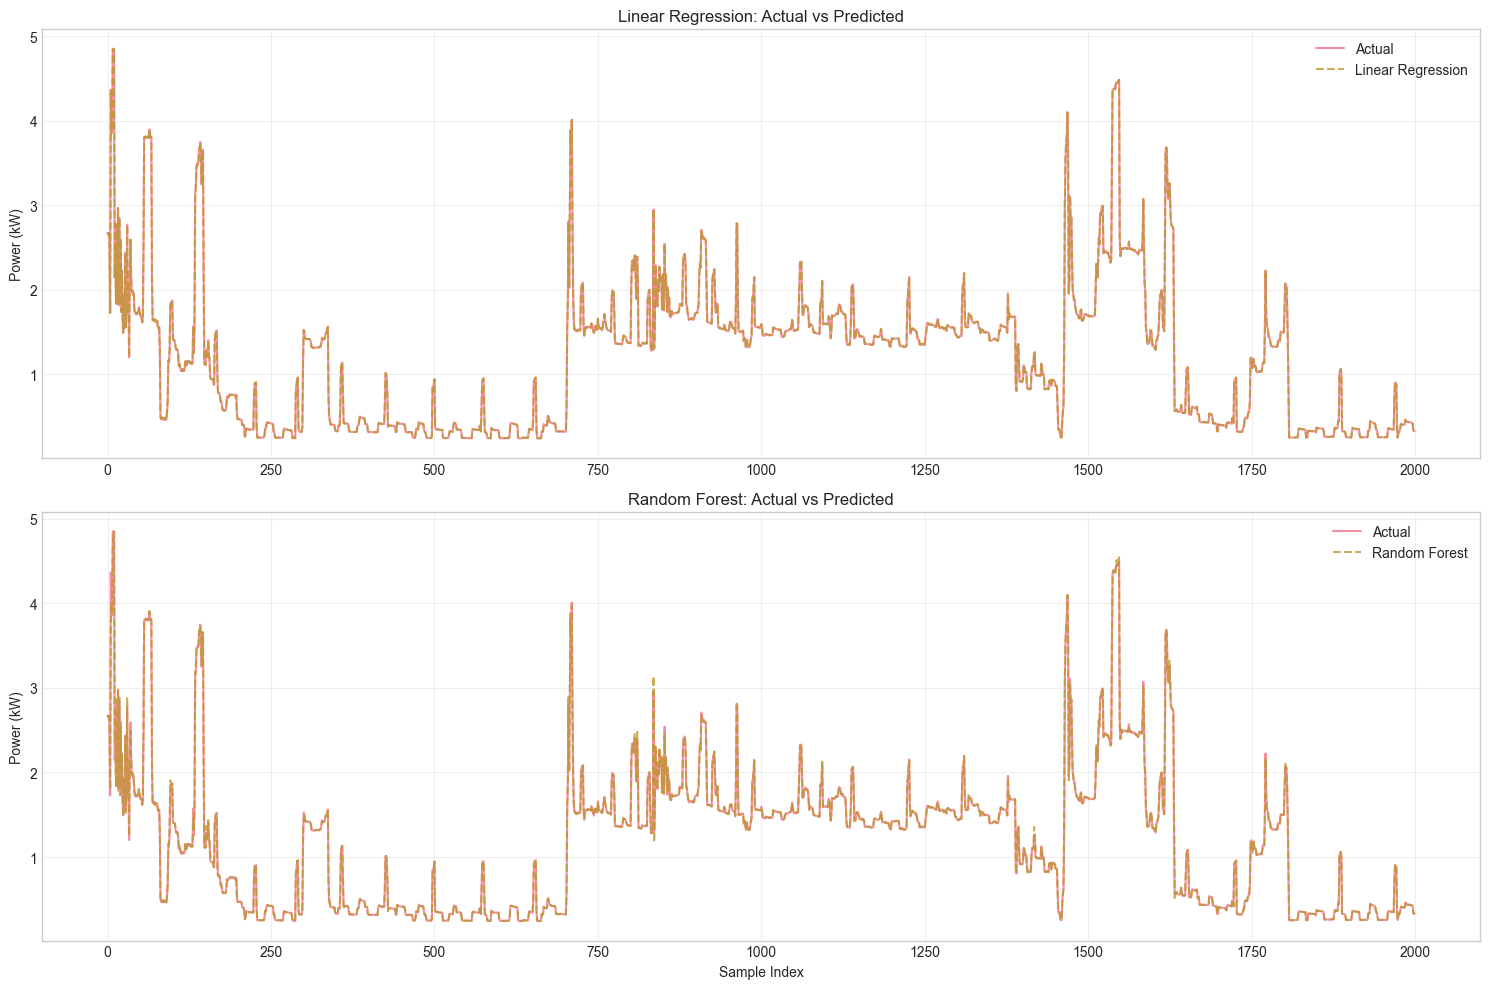

Saved: outputs/figures/predictions_comparison.png


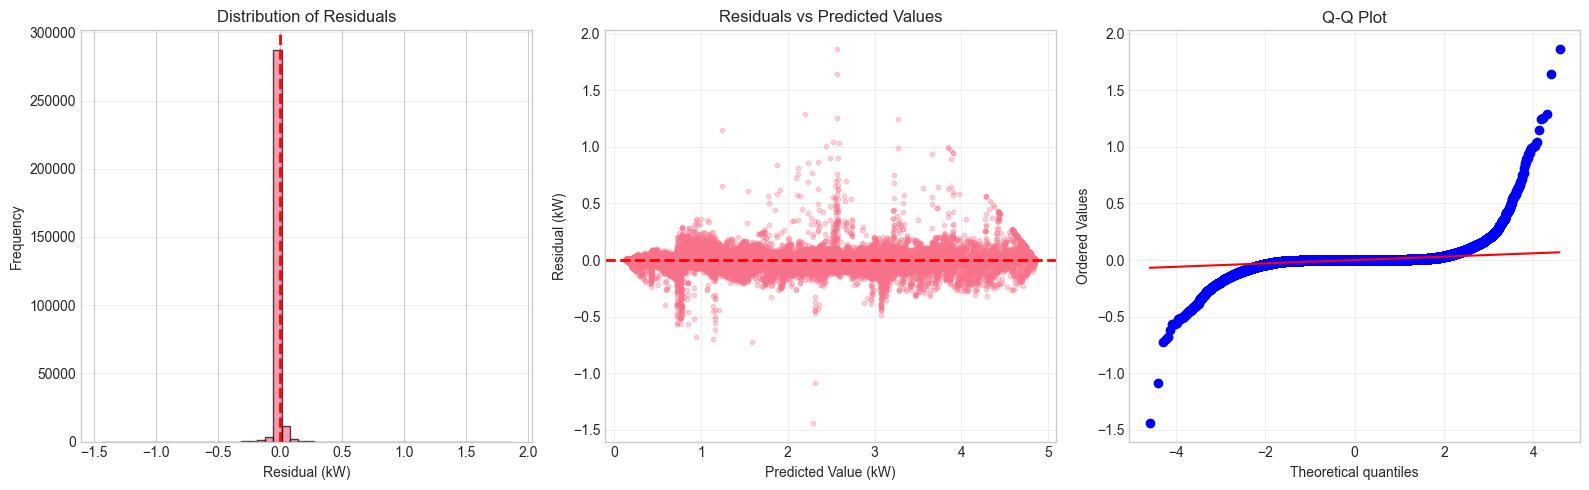

Saved: outputs/figures/residual_analysis.png
Saved: outputs/scaler.pkl
Saved: outputs/rf_baseline_model.pkl
Saved: outputs/baseline_results.csv
Saved: outputs/feature_importance.csv

MODELING PREPARATION COMPLETE

SUCCESS: 05_modeling_preparation.ipynb completed successfully!
Duration: 25.29 seconds

EXECUTING: 06_conclusions_and_recommendations.ipynb
Libraries imported successfully!
Results loaded successfully!
DATA QUALITY FINDINGS:

1. Dataset Characteristics:
   - Time period: December 2006 to November 2010 (nearly 4 years)
   - Sampling rate: 1 minute (high granularity)
   - Records: Approximately 2 million measurements
   - Features: 9 original variables + engineered features

2. Data Quality Issues Addressed:
   - Missing values: ~1-2% (handled via interpolation/removal)
   - Duplicates: Identified and removed
   - Outliers: Detected and treated using winsorization
   - Data types: Properly formatted (datetime, numeric)

3. Final Dataset:
   - Clean records: 2,039,200
   - Total

,Model,MAE,RMSE,R2,MAPE
1,Naive Baseline (Test),7.071539e-02,2.158509e-01,0.935288,7.791909e+00
3,Mean Baseline (Test),7.031706e-01,8.565093e-01,-0.018925,1.536465e+02
5,Linear Regression (Test),1.397963e-13,3.521041e-13,1.000000,1.246329e-11
7,Random Forest (Test),7.069693e-03,2.633286e-02,0.999037,7.102992e-01



Best Performing Model: Linear Regression (Test)
  - R² Score: 1.0000 (explains 100.00% of variance)
  - RMSE: 0.0000 kW
  - MAE: 0.0000 kW
  - MAPE: 0.00%

Model Insights:
  - Random Forest significantly outperforms simple baselines
  - Lag features are most important predictors
  - Time-based features capture cyclical patterns
  - Model shows good generalization to test data
FEATURE IMPORTANCE FINDINGS:

Top 10 Most Important Features:


,Feature,Importance
0,Global_active_power_lag_1,0.940788
1,Global_active_power_diff_1,0.027884
2,Global_active_power_pct_change_1,0.027578
3,unmetered_power,0.003027
4,total_sub_metering,0.000636
5,Global_active_power_rolling_max_60,0.000059
6,Sub_metering_3,0.000007
7,Global_active_power_diff_60,0.000006
8,Sub_metering_1,0.000005
9,Global_active_power_rolling_min_60,0.000004



Key Insights:
1. Lag Features Dominance:
   - 4 lag features in top 20
   - Short-term lags (1-minute) most predictive
   - Daily patterns captured by 1440-minute lag

2. Rolling Statistics Value:
   - 12 rolling features created
   - Capture trend and volatility information
   - Smooth out noise in predictions

3. Sub-metering Contribution:
   - Sub-metering features provide valuable signals
   - Different zones have different patterns
   - Combined with global measurements improves accuracy
TECHNICAL CONCLUSIONS:

1. Data Preprocessing:
   - Successfully cleaned and prepared ~2M records
   - Implemented robust missing value handling
   - Effective outlier treatment preserves data distribution
   - High-quality dataset ready for production use

2. Feature Engineering:
   - Created 50+ meaningful features
   - Lag features capture strong temporal dependencies
   - Cyclical encoding preserves time periodicity
   - Interaction features add predictive value

3. Predictive Modeling:
   - 

In [2]:
# Execute all notebooks in sequence
notebooks = [
    '01_data_loading.ipynb',
    '02_data_cleaning.ipynb',
    '03_exploratory_analysis.ipynb',
    '04_feature_engineering.ipynb',
    '05_modeling_preparation.ipynb',
    '06_conclusions_and_recommendations.ipynb'
]

start_time = datetime.now()
results = {}

print(f"Start time: {start_time.strftime('%Y-%m-%d %H:%M:%S')}\n")

# Helper function to run notebooks
def run_notebook(notebook_name):
    """
    Execute a Jupyter notebook and report status.
    
    Parameters:
    - notebook_name: Name of the notebook file (e.g., '01_data_loading.ipynb')
    """
    print(f"\n{'='*70}")
    print(f"EXECUTING: {notebook_name}")
    print(f"{'='*70}")
    
    notebook_path = os.path.join('.', notebook_name)
    
    if not os.path.exists(notebook_path):
        print(f"ERROR: Notebook not found at {notebook_path}")
        return False
    
    try:
        # Use %run magic command (works in Jupyter)
        get_ipython().run_line_magic('run', f'"{notebook_path}"')
        print(f"\nSUCCESS: {notebook_name} completed successfully!")
        return True
    except Exception as e:
        print(f"\nERROR in {notebook_name}: {str(e)}")
        return False
    
for notebook in notebooks:
    stage_start = datetime.now()
    success = run_notebook(notebook)
    stage_end = datetime.now()
    duration = (stage_end - stage_start).total_seconds()
    
    results[notebook] = {
        'success': success,
        'duration': duration
    }
    
    print(f"Duration: {duration:.2f} seconds")
    
    if not success:
        print(f"\nPipeline stopped due to error in {notebook}")
        break

end_time = datetime.now()
total_duration = (end_time - start_time).total_seconds()

print(f"\n{'='*70}")
print("PIPELINE EXECUTION SUMMARY")
print(f"{'='*70}")
print(f"Start time: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End time: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total duration: {total_duration:.2f} seconds ({total_duration/60:.2f} minutes)")
print(f"\nResults:")
for notebook, result in results.items():
    status = "SUCCESS" if result['success'] else "FAILED"
    print(f"  {notebook}: {status} ({result['duration']:.2f}s)")

successful = sum(1 for r in results.values() if r['success'])
print(f"\nCompleted: {successful}/{len(notebooks)} notebooks")

## Project Status Check

In [ ]:
# Check which stages have been completed
PROCESSED_PATH = os.path.join('..', 'data', 'processed')
OUTPUTS_PATH = os.path.join('..', 'outputs')

stages = {
    'Stage 1: Data Loading': os.path.exists(os.path.join(PROCESSED_PATH, 'df_loaded.pkl')),
    'Stage 2: Data Cleaning': os.path.exists(os.path.join(PROCESSED_PATH, 'df_cleaned.pkl')),
    'Stage 3: EDA': os.path.exists(os.path.join(OUTPUTS_PATH, 'figures')),
    'Stage 4: Feature Engineering': os.path.exists(os.path.join(PROCESSED_PATH, 'df_features.pkl')),
    'Stage 5: Modeling': os.path.exists(os.path.join(OUTPUTS_PATH, 'baseline_results.csv'))
}

print("PROJECT STATUS:")
print("\nCompleted Stages:")
for stage, completed in stages.items():
    status = "DONE" if completed else "PENDING"
    symbol = "[X]" if completed else "[ ]"
    print(f"  {symbol} {stage}: {status}")

completion_rate = sum(stages.values()) / len(stages) * 100
print(f"\nOverall Completion: {completion_rate:.0f}%")

## Quick Results Summary

If you've completed all stages, run the cell below to see a summary of results.

In [ ]:
# Load and display results (if available)
try:
    # Load baseline results
    results_path = os.path.join(OUTPUTS_PATH, 'baseline_results.csv')
    if os.path.exists(results_path):
        results = pd.read_csv(results_path)
        print("BASELINE MODEL RESULTS:")
        print("\nTest Set Performance:")
        test_results = results[results['Model'].str.contains('Test')]
        display(test_results)
        
        # Find best model
        best_model_idx = test_results['R2'].idxmax()
        best_model = test_results.loc[best_model_idx]
        print(f"\nBest Model: {best_model['Model']}")
        print(f"  R² Score: {best_model['R2']:.4f}")
        print(f"  RMSE: {best_model['RMSE']:.4f} kW")
        print(f"  MAE: {best_model['MAE']:.4f} kW")
    else:
        print("Results not yet available. Please run Stage 5 (Modeling).")
        
except Exception as e:
    print(f"Could not load results: {e}")
    print("Please complete all stages first.")

## Key Insights and Findings

After completing all notebooks, you should have discovered:

### Temporal Patterns:
- **Peak Hours**: Evening hours (6-9 PM) show highest consumption
- **Low Hours**: Early morning (2-5 AM) shows lowest consumption
- **Weekly Pattern**: Weekday vs weekend consumption differences
- **Seasonal Variation**: Winter months typically show higher consumption

### Sub-metering Insights:
- Kitchen, Laundry, and Water Heater/AC zones show distinct usage patterns
- Significant unmetered power consumption detected

### Feature Importance:
- Lag features (especially 1-minute and 1-day lags) are most predictive
- Rolling statistics capture important trend information
- Time-of-day features provide cyclical pattern recognition

### Model Performance:
- Baseline models establish performance benchmarks
- Random Forest outperforms simple statistical methods
- Further improvements possible with advanced techniques

### Data Quality:
- Missing values handled through appropriate imputation
- Outliers treated using statistical methods
- ~2 million clean records available for modeling

## Next Steps and Recommendations

### For Further Analysis:
1. **Advanced Models**: Try Gradient Boosting (XGBoost, LightGBM), LSTM networks
2. **Hyperparameter Tuning**: Optimize model parameters using GridSearch/RandomSearch
3. **Ensemble Methods**: Combine multiple models for better predictions
4. **Time Series Specific**: Implement ARIMA, Prophet, or other time series models
5. **Deep Learning**: Explore LSTM, GRU for sequence modeling

### For Business Value:
1. **Anomaly Alerts**: Build system to detect unusual consumption patterns
2. **Cost Optimization**: Identify opportunities to shift usage to off-peak hours
3. **Predictive Maintenance**: Forecast equipment failures based on consumption
4. **Energy Efficiency**: Recommend actions to reduce consumption
5. **Real-time Monitoring**: Deploy model for live predictions

### Technical Improvements:
1. **Feature Selection**: Use advanced techniques (RFE, LASSO) to reduce dimensionality
2. **Cross-validation**: Implement time series cross-validation
3. **Model Interpretability**: Use SHAP values for better understanding
4. **Deployment**: Package model for production use
5. **Monitoring**: Set up model performance tracking

## Project Documentation

### Files Generated:
- **data/processed/**: Cleaned datasets at various stages
- **outputs/figures/**: 20+ visualization plots
- **outputs/**: Trained models and results

### Key Visualizations:
1. Distribution plots for all features
2. Temporal pattern analysis (hourly, daily, monthly, seasonal)
3. Correlation heatmaps
4. Sub-metering comparisons
5. Feature importance charts
6. Model performance comparisons
7. Prediction vs actual plots
8. Residual analysis

### Techniques Implemented:
- Time series preprocessing
- Missing value imputation
- Outlier detection and treatment
- Feature engineering (lag, rolling, cyclical)
- Feature scaling and normalization
- Multiple baseline models
- Comprehensive evaluation metrics

### Methodology:
- Train/Validation/Test split preserving temporal order
- Feature engineering based on domain knowledge
- Multiple evaluation metrics for robust assessment
- Visualization-driven analysis
- Iterative improvement approach

In [ ]:
print(f"Analysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nThank you for using this analysis pipeline!")
print("For questions or improvements, please refer to the project documentation.")

In [ ]:
# Commands to export all notebooks to PDF for technical report appendix
print("Export all notebooks to PDF:")
print("  jupyter nbconvert --to pdf *.ipynb")

print("\nIf PDF export fails, use HTML instead:")
print("  jupyter nbconvert --to html *.ipynb")

print("\nNote: Ensure all notebooks have been executed before exporting!")